# Proyecto Integrador: Calidad del Aire en Lima Metropolitana
## Versión unificada &mdash; explicaciones como texto, fuera del código

**Curso:** Ciencia de Datos Ambientales &mdash; Proyecto Integrador\
**Estación analizada:** San Borja, Lima\
**Construcción de este archivo:** fusión textual exacta de dos notebooks, sin modificar ninguno de los dos originales ni reescribir ninguna línea de código:
- **Parte 1** (hasta "Rosa de viento" inclusive): copia idéntica de `PROYECTOFINAL_PRO_ORDENADO.ipynb`.
- **Parte 2** (desde "Verificación de no linealidad de variables" hasta el final): copia literal de `PF_CIENCIAA.ipynb`.

**Diferencia con la versión anterior:** las explicaciones detalladas de la sección de Modelado Predictivo ahora van en celdas de **texto (markdown)** separadas, justo antes de cada bloque de código. Las celdas de código quedan **exactamente iguales** al archivo original, sin ningún comentario `#` agregado dentro de ellas.

---
# PARTE 1 &mdash; FUENTES DE DATOS UTILIZADAS

| Archivo | Contenido | Formato |
|---|---|---|
| `DATOS_CONTAMINANTE_SBORJA.xlsx` | PM2.5 y PM10 horarios | Excel, hoja `SAN BORJA` |
| `DATOS_METEOROLOGICOS_SBORJA.xlsx` | Temperatura, humedad, viento, precipitación horarios | Excel, hoja `SAN BORJA` |

Ambas fuentes provienen de la estación de monitoreo de San Borja (formato
análogo al de SENAMHI/OEFA) y comparten la misma resolución horaria, lo que
permite combinarlas por fecha y hora en la fase de Transformación (Parte 2).
Estándar de referencia para el análisis: **ECA para Aire, D.S. N.º
003-2017-MINAM** (PM2.5 = 50 &micro;g/m3, PM10 = 100 &micro;g/m3, promedio 24 h).

## 3.1 Descripción del problema ambiental

**Problema:** Lima Metropolitana registra de forma recurrente concentraciones de material
particulado (PM2.5 y PM10) que exceden los Estándares de Calidad Ambiental (ECA) para aire
establecidos por el **Decreto Supremo N.º 003-2017-MINAM**:

| Contaminante | ECA (promedio 24 h) | ECA (promedio anual) |
|---|---|---|
| PM2.5 | 50 &micro;g/m3 | 25 &micro;g/m3 |
| PM10  | 100 &micro;g/m3 | 50 &micro;g/m3 |

*(Fuente: D.S. N.º 003-2017-MINAM, "Aprueban Estándares de Calidad Ambiental (ECA) para Aire",
publicado el 8 de junio de 2017 &mdash; Ministerio del Ambiente / DIGESA.)*

La exposición sostenida a PM2.5 y PM10 está asociada a enfermedades respiratorias y
cardiovasculares. Lima concentra la mayor parte de la población y el parque automotor
del país, lo que la convierte en una de las zonas de mayor riesgo de contaminación
atmosférica urbana del Perú.

**Contexto territorial:** este proyecto analiza los datos horarios de la estación de
monitoreo **San Borja**, distrito residencial y comercial de Lima con tránsito vehicular
denso, a partir de dos fuentes:
- `DATOS_CONTAMINANTE_SBORJA.xlsx` &mdash; concentraciones horarias de PM2.5 y PM10.
- `DATOS_METEOROLOGICOS_SBORJA.xlsx` &mdash; variables meteorológicas horarias (temperatura,
  humedad relativa, precipitación, velocidad y dirección del viento).

**Evidencia cuantitativa de la relevancia del problema:** la Sección 10 (análisis
exploratorio) calcula el porcentaje exacto de horas en que PM2.5 y PM10 superan el ECA
durante 2022-2023, confirmando con datos si el problema es sistemático en el periodo
estudiado, no anecdótico.

## 3.2 Indicadores ambientales clave e hipótesis

**Indicadores seleccionados:**
1. **PM2.5** (&micro;g/m3) &mdash; material particulado fino, el de mayor riesgo respiratorio.
2. **PM10** (&micro;g/m3) &mdash; material particulado grueso, asociado a polvo y resuspensión.
3. **Velocidad del viento** (m/s) &mdash; variable meteorológica de dispersión de contaminantes.
4. **Humedad relativa (%) y temperatura (&deg;C)** &mdash; variables asociadas a la estabilidad
   atmosférica y a la acumulación de partículas.

**Hipótesis a verificar con los datos** (se contrastan en la Sección 12.1, Validación de hipótesis):

- **H1:** La concentración media de PM2.5 y PM10 es más alta en los meses de otoño-invierno
  (mayo-agosto) que en los meses de verano (diciembre-marzo), por la menor mezcla vertical
  del aire limeno en invierno.
- **H2:** Existe una correlación negativa entre la velocidad del viento y las
  concentraciones de PM2.5/PM10 (a mayor viento, mayor dispersión, menor concentración).
- **H3:** La concentración de PM2.5/PM10 presenta un patrón horario con picos asociados a
  las horas de mayor tráfico vehicular (mañana y noche), y valores mínimos en la madrugada.

## 3.3 Arquitectura y flujo de datos

**Fuente de datos:** estación de monitoreo San Borja (formato análogo al de SENAMHI/OEFA),
entregada como dos archivos Excel horarios.

**Formato:** Excel (`.xlsx`), hoja `SAN BORJA` en ambos archivos.

**Pipeline de procesamiento (todo dentro de este notebook):**

1. **Carga:** lectura de ambos archivos Excel con `pandas.read_excel` (motor `openpyxl`).
2. **Limpieza:** normalización de encabezados, clave fecha-hora común, marcadores `S/D`
   convertidos a valores numéricos faltantes.
3. **Transformación:** unión (`merge`) de contaminantes y meteorología por fecha-hora,
   imputación de faltantes de PM2.5/PM10 cuando hay meteorología disponible, filtrado a
   filas completas.
4. **Análisis:** estadística descriptiva, series de tiempo, correlaciones, detección de
   outliers (criterio IQR), validación de hipótesis.
5. **Modelamiento:** regresión lineal y polinomial para predecir PM2.5.
6. **Consumo:** resultados exportados a CSV/PNG y resumidos en un dashboard interactivo
   (`dashboard.html`, generado fuera de este notebook) publicado en GitHub Pages.

**Diseño listo para Google Drive:** toda lectura/escritura de archivos de este notebook
pasa por las funciones `leer_excel`, `leer_csv` y `guardar_csv` (Sección 2). Hoy leen y
guardan archivos locales; cuando el equipo conecte Google Drive, **solo se cambia la
variable `CARPETA_DATOS`** (o el interior de esas tres funciones si se usa la API de
Drive) &mdash; el resto del notebook no se modifica.

---
# PARTE 2 &mdash; PIPELINE DE PROCESAMIENTO
### Carga &rarr; Limpieza &rarr; Transformación

**Nota metodológica:** en este proyecto la unión de las dos fuentes
(`pd.merge`) se clasifica como **Transformación** (combina/reestructura
datos) y ocurre *antes* de la imputación de faltantes, porque solo después
de unir contaminantes y meteorología se puede evaluar correctamente qué
filas quedaron incompletas. La limpieza de formato (fechas, `S/D` -> NaN)
sí se hace primero, sobre cada fuente por separado.

## FASE 2.1 &mdash; CARGA

## 1. Importar librerías

Todas las librerías de análisis fueron vistas en los laboratorios del curso: `pandas` /
`numpy` (Lab 3.1), `matplotlib` / `seaborn` (Lab 4.1-4.2), y el `scikit-learn` básico del
Lab 7.1 (`LinearRegression`, `PolynomialFeatures`, `train_test_split`, `cross_val_score`,
métricas). La única excepción es `openpyxl`, requerido por `pandas` para abrir `.xlsx`.

In [ ]:
# -- Librerias estandar de ciencia de datos (Lab 3.1, 4.1, 4.2) --
from pathlib import Path            # manejo de rutas de archivo
import warnings                     # silenciar avisos menores (mismo patron del Lab 5.2)
import numpy as np                  # operaciones numericas
import pandas as pd                 # manejo de datos tabulares
import matplotlib.pyplot as plt     # graficos
import matplotlib.patches as mpatches
import seaborn as sns               # graficos estadisticos

warnings.filterwarnings("ignore", category=FutureWarning)

# -- Modelado (Lab 7.1 - Fundamentos de Machine Learning) --
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# openpyxl es el motor que pandas necesita para leer archivos .xlsx.
# No agrega tecnicas de analisis nuevas: solo permite abrir el formato de archivo
# que entrega la estacion San Borja.
import importlib
try:
    importlib.import_module("openpyxl")
    print("openpyxl disponible.")
except ModuleNotFoundError:
    print("ADVERTENCIA: falta 'openpyxl'. Instalar con: pip install openpyxl")

get_ipython().run_line_magic('matplotlib', 'inline')
sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente.")


## 2. Configuración del entorno y rutas de datos (listo para Google Drive)

Esta sección concentra **todo** el acceso a archivos del proyecto en un solo lugar.
El notebook detecta automáticamente si se ejecuta en Google Colab; si es así, monta
Google Drive. Si se ejecuta localmente (como ahora), usa la carpeta del proyecto.

Cuando el equipo conecte Google Drive de forma definitiva, el único cambio necesario es
la ruta `CARPETA_DATOS` (y, si se usa la API de Drive en vez del montaje clásico, el
interior de `leer_excel` / `leer_csv` / `guardar_csv`). El resto del notebook siempre
llama a estas funciones, nunca a `pd.read_excel` o `to_csv` directamente.

In [ ]:
# -- Deteccion automatica del entorno (Colab vs. local) --
try:
    from google.colab import drive
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if EN_COLAB:
    drive.mount('/content/drive')
    # TODO (futuro): reemplazar por la carpeta real del proyecto en Google Drive, ej:
    # CARPETA_DATOS = Path('/content/drive/MyDrive/ProyectoAireSanBorja')
    CARPETA_DATOS = Path('/content/drive/MyDrive/ProyectoAireSanBorja')
else:
    # Ejecucion local: los archivos .xlsx estan en la misma carpeta que este notebook.
    CARPETA_DATOS = Path('.')

CARPETA_SALIDA = CARPETA_DATOS  # los archivos generados (CSV, PNG) se guardan en el mismo lugar

print(f"Entorno detectado : {'Google Colab' if EN_COLAB else 'Local'}")
print(f"Carpeta de datos  : {CARPETA_DATOS.resolve()}")


In [ ]:
# -- Funciones de acceso a datos: punto UNICO de lectura/escritura del proyecto --
# Si en el futuro los datos se leen/escriben con la API de Google Drive en vez de
# rutas de archivo locales, SOLO se modifica el interior de estas funciones.

def ruta_entrada(nombre_archivo):
    """Devuelve la ruta completa de un archivo de entrada (Excel/CSV)."""
    return CARPETA_DATOS / nombre_archivo


def ruta_salida(nombre_archivo):
    """Devuelve la ruta completa donde se debe guardar un archivo generado."""
    return CARPETA_SALIDA / nombre_archivo


def leer_excel(nombre_archivo, hoja):
    """Lee una hoja de un archivo Excel del proyecto."""
    return pd.read_excel(ruta_entrada(nombre_archivo), sheet_name=hoja, engine="openpyxl")


def guardar_csv(df, nombre_archivo):
    """Guarda un DataFrame como CSV (conservando 'S/D' como texto) y devuelve la ruta usada."""
    ruta = ruta_salida(nombre_archivo)
    df.to_csv(ruta, index=False, encoding="utf-8-sig")
    return ruta


def leer_csv(nombre_archivo, **kwargs):
    """Lee un CSV generado por este mismo proyecto."""
    return pd.read_csv(ruta_entrada(nombre_archivo), **kwargs)


print("Funciones definidas: ruta_entrada, ruta_salida, leer_excel, guardar_csv, leer_csv")


In [ ]:
# -- Archivos de entrada y salida --
ARCHIVO_CONTAMINANTES = "DATOS_CONTAMINANTE_SBORJA.xlsx"
ARCHIVO_METEOROLOGIA  = "DATOS_METEOROLOGICOS_SBORJA.xlsx"

ARCHIVO_DATA_FINAL    = "datafinal.csv"        # contaminantes + meteorologia unidos
ARCHIVO_COMPLETADO    = "completado.csv"       # con imputacion de PM2.5/PM10
ARCHIVO_DATOS_LIMPIOS = "datos_limpios.csv"    # solo filas completas

# -- Nombres de columnas objetivo y predictoras --
PM25_COL = "PM25"
PM10_COL = "PM10"
TEMP_COL = "TEMPERATURA"
HUM_COL  = "HUMEDAD_RELATIVA"
WIND_COL = "VELOCIDAD_VIENTO"

TARGET_COLS = [PM25_COL, PM10_COL]
METEO_COLS  = [TEMP_COL, HUM_COL, WIND_COL]

# -- Marcador de dato faltante en los archivos originales --
NO_DATA_TEXT = "S/D"
MISSING_MARKERS = {"", "S/D", "s/d", "SD", "sd", "NA", "N/A", "na", "n/a", "nan", "NaN", "None", None}

# -- Estandares de Calidad Ambiental para aire (D.S. N.o 003-2017-MINAM) --
ECA_PM25 = 50   # ug/m3, promedio 24 horas
ECA_PM10 = 100  # ug/m3, promedio 24 horas

print("Configuracion lista.")
print(f"  Entrada contaminantes : {ruta_entrada(ARCHIVO_CONTAMINANTES)}")
print(f"  Entrada meteorologia  : {ruta_entrada(ARCHIVO_METEOROLOGIA)}")


---
## 3. Lectura de datos

Se leen las hojas `SAN BORJA` de ambos archivos Excel a través de `leer_excel`
(la función centralizada definida en la Sección 2), en vez de llamar a
`pd.read_excel` directamente.

In [ ]:
cont  = leer_excel(ARCHIVO_CONTAMINANTES, hoja="SAN BORJA")
meteo = leer_excel(ARCHIVO_METEOROLOGIA,  hoja="SAN BORJA")

print(f"Contaminantes : {cont.shape[0]:,} filas x {cont.shape[1]} columnas")
print(f"Meteorologia  : {meteo.shape[0]:,} filas x {meteo.shape[1]} columnas")
print()
print("Columnas contaminantes :", cont.columns.tolist())
print("Columnas meteorologia  :", meteo.columns.tolist())


---
## FASE 2.2 &mdash; LIMPIEZA

Se estandarizan formatos y valores inválidos **antes** de combinar las
fuentes: parseo de fecha/hora, normalización de nombres de columna y
conversión de las marcas `S/D` (Sin Dato) de la estación a `NaN` explícito
de `pandas`, para que puedan tratarse con las herramientas estadísticas
del curso en vez de quedar como texto.

---
## 4. Funciones auxiliares de preprocesamiento

Se definen tres funciones reutilizables usando solo herramientas vistas en clase
(métodos de cadenas de texto del Lab 2.4, `pandas`/`numpy` del Lab 3.1):
- `crear_fecha_hora`: combina fecha y hora en un único `datetime`.
- `buscar_columna`: encuentra una columna por nombre, ignorando mayúsculas, tildes y
  unidades entre paréntesis, usando solo métodos de texto básicos (`.lower()`, `.strip()`,
  `.replace()`, `.split()`) &mdash; **sin** el módulo `re` (expresiones regulares) ni
  `unicodedata`, que no se vieron en clase.
- `convertir_a_numero`: reemplaza los marcadores `S/D` por valores numéricos faltantes.

In [ ]:
def crear_fecha_hora(df, col_fecha, col_hora):
    """Combina una columna de fecha y una de hora en un unico datetime."""
    fecha      = pd.to_datetime(df[col_fecha], errors="coerce")
    hora       = pd.to_timedelta(df[col_hora].astype(str), errors="coerce")
    fecha_hora = fecha.dt.normalize() + hora
    fecha_hora = fecha_hora.fillna(fecha)
    return fecha_hora


def normalizar_texto(texto):
    """Deja un nombre de columna en minusculas, sin tildes ni simbolos,
    usando solo metodos basicos de cadenas de texto (Lab 2.4)."""
    texto = str(texto).strip().lower()
    reemplazos = {
        chr(225): "a", chr(233): "e", chr(237): "i",
        chr(243): "o", chr(250): "u", chr(241): "n",
        "(": " ", ")": " ", chr(176): " ", "%": " ", "/": " ", ".": " ", ",": " ",
    }
    for original, nuevo in reemplazos.items():
        texto = texto.replace(original, nuevo)
    return " ".join(texto.split())


def buscar_columna(df, patron):
    """Busca una columna cuyo nombre normalizado coincida (exacto o parcial) con el patron dado."""
    patron_norm = normalizar_texto(patron)
    for col in df.columns:
        if normalizar_texto(col) == patron_norm:
            return col
    for col in df.columns:
        if patron_norm in normalizar_texto(col):
            return col
    raise ValueError("No se encontro columna para " + repr(patron) + ". Columnas disponibles: " + str(list(df.columns)))


def convertir_a_numero(serie):
    """Reemplaza marcadores de dato faltante (S/D, NA, etc.) por NaN y convierte a numero."""
    serie = serie.astype(str).str.strip()
    serie = serie.replace({
        "S/D": np.nan, "s/d": np.nan, "SD": np.nan, "sd": np.nan,
        "": np.nan, " ": np.nan, "NA": np.nan, "N/A": np.nan,
        "nan": np.nan, "NaN": np.nan, "None": np.nan,
    })
    serie = serie.str.replace(",", ".", regex=False)
    return pd.to_numeric(serie, errors="coerce")


print("Funciones auxiliares definidas.")


---
## FASE 2.3 &mdash; TRANSFORMACIÓN

Se combinan (`pd.merge`) las dos fuentes en una sola tabla analizable y se
resuelven los valores faltantes resultantes de la unión (imputación
estadística). El resultado es el dataset único y limpio que alimenta el
análisis descriptivo de la Parte 3.

---
## 5. Unión de contaminantes y meteorología &rarr; `datafinal.csv`

Se crea la clave `_fecha_hora` en ambos DataFrames, se eliminan duplicados
meteorológicos y se realiza una unión (`pd.merge`, tipo `left`) usando contaminantes
como base. `pd.merge` es la forma estándar de `pandas` para combinar dos tablas por una
columna en común (aquí, la fecha-hora); es indispensable para este proyecto porque los
datos vienen en dos archivos separados que hay que cruzar.

In [ ]:
# -- Crear clave fecha-hora en ambos archivos --
cont["_fecha_hora"]  = crear_fecha_hora(cont,  "Fecha", "Hora")
meteo["_fecha_hora"] = crear_fecha_hora(meteo, "FECHA", "HORA")

# Descartar filas de contaminantes sin fecha valida
cont = cont[cont["_fecha_hora"].notna()].copy()

# Si hay fecha-hora repetida en meteorologia, conservar solo el primer registro
meteo = meteo.drop_duplicates(subset=["_fecha_hora"], keep="first").copy()

print(f"Contaminantes validos  : {cont.shape[0]:,} filas")
print(f"Meteorologia sin dupl. : {meteo.shape[0]:,} filas")


In [ ]:
# -- Seleccionar y renombrar columnas meteorologicas usando buscar_columna --
col_temp = buscar_columna(meteo, "temperatura")
col_hum  = buscar_columna(meteo, "humedad relativa")
col_prec = buscar_columna(meteo, "precipitacion")
col_wind = buscar_columna(meteo, "velocidad de viento")
col_dir  = buscar_columna(meteo, "direccion de viento")

meteo_sel = meteo[["_fecha_hora", col_temp, col_hum, col_prec, col_wind, col_dir]].copy()
meteo_sel = meteo_sel.rename(columns={
    col_temp: "TEMPERATURA",
    col_hum:  "HUMEDAD_RELATIVA",
    col_prec: "PRECIPITACION",
    col_wind: "VELOCIDAD_VIENTO",
    col_dir:  "DIRECCION_VIENTO",
})

print("Columnas meteorologicas seleccionadas:", meteo_sel.columns.tolist())


In [ ]:
# -- Union: contaminantes como base (left join) --
datos = pd.merge(cont, meteo_sel, on="_fecha_hora", how="left")
datos = datos.drop(columns=["_fecha_hora"])

# Convertir Anio, Mes, Dia a numeros enteros (si existen esas columnas)
for patron in ["ano", "mes", "dia"]:
    encontrada = False
    for col in datos.columns:
        if normalizar_texto(col) == patron:
            datos[col] = pd.to_numeric(datos[col], errors="coerce").astype("Int64")
            print(f"Columna convertida a entero: {col}")
            encontrada = True
            break
    if not encontrada:
        print(f"No se encontro columna para: {patron}")

# Rellenar vacios con el marcador S/D (consistente con el resto del archivo original)
datos = datos.fillna(NO_DATA_TEXT)

# -- Guardar datafinal.csv usando la funcion centralizada (lista para Drive) --
ruta_guardada = guardar_csv(datos, ARCHIVO_DATA_FINAL)

print(f"\nArchivo generado: {ruta_guardada}")
print(f"Filas    : {datos.shape[0]:,}")
print(f"Columnas : {datos.shape[1]}")
datos.head()


---
## 6. Evaluación de datos faltantes antes de imputar

Se cuantifica la proporción de valores `S/D` en cada variable clave antes de completar
los datos.

In [ ]:
df = leer_csv(ARCHIVO_DATA_FINAL, dtype=str, keep_default_na=False)

requeridas = TARGET_COLS + METEO_COLS + ["PRECIPITACION", "DIRECCION_VIENTO"]
faltantes  = [c for c in requeridas if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas en {ARCHIVO_DATA_FINAL}: {faltantes}")

print(f"Filas cargadas: {len(df):,}")

cols_analizar = TARGET_COLS + ["TEMPERATURA", "HUMEDAD_RELATIVA", "PRECIPITACION",
                               "VELOCIDAD_VIENTO", "DIRECCION_VIENTO"]

resumen_faltantes = pd.DataFrame({
    "Variable": cols_analizar,
    "Cantidad_faltante": [(df[c].isin(MISSING_MARKERS)).sum() for c in cols_analizar],
})
resumen_faltantes["Porcentaje_faltante"] = (
    resumen_faltantes["Cantidad_faltante"] / len(df) * 100
).round(2)

print("\nDatos faltantes por variable:")
print(resumen_faltantes.to_string(index=False))


In [ ]:
# -- Visualizacion: porcentaje de datos faltantes --
fig, ax = plt.subplots(figsize=(9, 5))

colores = ["#e74c3c" if p > 50 else "#e67e22" if p > 30 else "#3498db"
           for p in resumen_faltantes["Porcentaje_faltante"]]

ax.barh(resumen_faltantes["Variable"], resumen_faltantes["Porcentaje_faltante"],
        color=colores, edgecolor="white", linewidth=0.8)

for i, (val, cant) in enumerate(zip(resumen_faltantes["Porcentaje_faltante"], resumen_faltantes["Cantidad_faltante"])):
    ax.text(val + 0.5, i, f"{val:.1f}%  ({cant:,})", va="center", fontsize=9)

ax.set_xlabel("Porcentaje faltante (%)")
ax.set_title("Datos faltantes por variable - Estacion San Borja", fontsize=13)
ax.set_xlim(0, 100)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(ruta_salida("datos_faltantes_previo_imputacion.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## 7. Tratamiento de datos faltantes en PM2.5 y PM10 (MICE)

**Método usado:** imputación múltiple por ecuaciones encadenadas (**MICE**, `statsmodels.imputation.mice.MICEData`).

*Fuera del currículo de las Sesiones: `statsmodels.imputation.mice` no aparece en ninguno de los 13 notebooks de la carpeta "Sesiones". Se usa aquí a pedido explícito, reemplazando la imputación curricular (promedio por mes-hora) que tenía esta sección.*

**Criterio aplicado:**
- Solo se imputan `PM25` y `PM10` cuando las tres variables meteorológicas auxiliares (temperatura, humedad relativa, velocidad del viento) están disponibles en la misma fila.
- MICE modela cada variable con datos faltantes en función de las demás, de forma iterativa (`N_MICE_ITER = 10` iteraciones), a diferencia del método curricular que usa un promedio fijo por mes-hora.
- Los valores ya existentes de `PM25` y `PM10` nunca se modifican.

In [ ]:
# FUERA DEL CURRICULO DE LAS SESIONES: statsmodels.imputation.mice.
from statsmodels.imputation.mice import MICEData

N_MICE_ITER = 10  # cantidad de iteraciones del algoritmo MICE

df_imp = df.copy()

for col in TARGET_COLS + METEO_COLS:
    df_imp[col] = convertir_a_numero(df_imp[col])

# Filas donde las tres variables meteorologicas estan disponibles
mascara_meteo = (
    df_imp[TEMP_COL].notna() &
    df_imp[HUM_COL].notna()  &
    df_imp[WIND_COL].notna()
)

# Filas donde algun contaminante falta Y la meteorologia esta disponible
mascara_imputar = mascara_meteo & (
    df_imp[PM25_COL].isna() | df_imp[PM10_COL].isna()
)

print(f"Filas con meteorologia completa   : {mascara_meteo.sum():,}")
print(f"Filas candidatas a imputacion MICE: {mascara_imputar.sum():,}")


In [ ]:
# FUERA DEL CURRICULO DE LAS SESIONES: MICEData.
# -- Aplicar MICE en el subconjunto con meteorologia completa --
cols_modelo = ["pm25", "pm10", "temp", "hum", "wind"]

sub = df_imp.loc[mascara_meteo, TARGET_COLS + METEO_COLS].copy()
sub.columns = cols_modelo

# Guardar indices originales de filas que tenian NaN en PM25 o PM10
idx_pm25_faltante = df_imp.loc[mascara_meteo & df_imp[PM25_COL].isna()].index
idx_pm10_faltante = df_imp.loc[mascara_meteo & df_imp[PM10_COL].isna()].index

mice_data = MICEData(sub)
for _ in range(N_MICE_ITER):
    mice_data.update_all()

sub_imputado = mice_data.data

# Escribir valores imputados de vuelta al DataFrame principal
df_imp.loc[mascara_meteo, PM25_COL] = sub_imputado["pm25"].values
df_imp.loc[mascara_meteo, PM10_COL] = sub_imputado["pm10"].values

print(f"Iteraciones MICE ejecutadas: {N_MICE_ITER}")
print("Imputacion MICE completada.")


In [ ]:
# -- Restaurar S/D donde no habia meteorologia disponible, y guardar completado.csv --
df_out = df.copy()
for col in TARGET_COLS + METEO_COLS:
    df_out[col] = convertir_a_numero(df_out[col])

# Solo actualizar filas donde habia meteorologia completa
df_out.loc[mascara_meteo, PM25_COL] = df_imp.loc[mascara_meteo, PM25_COL]
df_out.loc[mascara_meteo, PM10_COL] = df_imp.loc[mascara_meteo, PM10_COL]

# Donde no habia meteorologia, se conserva el marcador S/D
df_out[PM25_COL] = df_out[PM25_COL].where(df_out[PM25_COL].notna(), other=NO_DATA_TEXT)
df_out[PM10_COL] = df_out[PM10_COL].where(df_out[PM10_COL].notna(), other=NO_DATA_TEXT)

ruta_guardada = guardar_csv(df_out, ARCHIVO_COMPLETADO)
print(f"Archivo guardado: {ruta_guardada}")
df_out.head()


---
## 8. Resumen de la imputación

Se compara la cantidad de datos faltantes antes y después de imputar.

In [ ]:
def contar_faltantes(serie):
    return (serie.astype(str).isin(MISSING_MARKERS) | serie.isna()).sum()

resumen_imputacion = pd.DataFrame({
    "Variable": TARGET_COLS,
    "Faltantes_antes": [contar_faltantes(df[PM25_COL]), contar_faltantes(df[PM10_COL])],
    "Faltantes_despues": [contar_faltantes(df_out[PM25_COL]), contar_faltantes(df_out[PM10_COL])],
})
resumen_imputacion["Datos_completados"] = (
    resumen_imputacion["Faltantes_antes"] - resumen_imputacion["Faltantes_despues"]
)

print("Resumen de imputacion:")
print(resumen_imputacion.to_string(index=False))


In [ ]:
# -- Grafico: comparacion de faltantes antes/despues de imputar --
resumen_grafico = resumen_imputacion.melt(
    id_vars="Variable",
    value_vars=["Faltantes_antes", "Faltantes_despues", "Datos_completados"],
    var_name="Estado", value_name="Cantidad",
)

plt.figure(figsize=(9, 5))
sns.barplot(data=resumen_grafico, x="Variable", y="Cantidad", hue="Estado", width=0.5)
plt.xlabel("Contaminante", fontsize=12)
plt.ylabel("Cantidad de registros", fontsize=12)
plt.title("Datos faltantes y completados (imputacion por promedio mes-hora)", fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Estado", fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.savefig(ruta_salida("comparacion_faltantes_completados.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## 9. Limpieza final: dataset completo sin valores faltantes

Se genera `datos_limpios.csv` conservando únicamente las filas donde todas las variables
clave tienen datos válidos: PM2.5, PM10, temperatura, humedad relativa, precipitación,
velocidad del viento y dirección del viento. Este archivo es el punto de partida del
análisis exploratorio.

In [ ]:
df_limpio = leer_csv(ARCHIVO_COMPLETADO, dtype=str, keep_default_na=False)

COLS_NUMERICAS = [PM25_COL, PM10_COL, "TEMPERATURA", "HUMEDAD_RELATIVA",
                  "VELOCIDAD_VIENTO", "DIRECCION_VIENTO", "PRECIPITACION"]

for col in COLS_NUMERICAS:
    df_limpio[col] = convertir_a_numero(df_limpio[col])

df_limpio["Fecha"] = pd.to_datetime(df_limpio["Fecha"], errors="coerce")

# PRECIPITACION se incluye en las columnas requeridas para que el archivo final
# quede realmente sin nulos en ninguna de sus columnas.
COLS_REQUERIDAS = ["Fecha", PM25_COL, PM10_COL, "TEMPERATURA", "HUMEDAD_RELATIVA",
                   "VELOCIDAD_VIENTO", "DIRECCION_VIENTO", "PRECIPITACION"]

n_antes = len(df_limpio)
df_limpio = df_limpio.dropna(subset=COLS_REQUERIDAS).copy()
df_limpio = df_limpio.sort_values("Fecha").reset_index(drop=True)
n_despues = len(df_limpio)

print(f"Filas antes de limpieza  : {n_antes:,}")
print(f"Filas eliminadas         : {n_antes - n_despues:,}  ({(n_antes-n_despues)/n_antes*100:.1f}%)")
print(f"Filas despues de limpieza: {n_despues:,}  ({n_despues/n_antes*100:.1f}%)")
print(f"Nulos restantes          : {df_limpio[COLS_REQUERIDAS].isna().sum().sum()}")


### 9.1 Resumen de cobertura temporal del dataset limpio

In [ ]:
df_limpio["Anio"] = df_limpio["Fecha"].dt.year

registros_por_anio = (
    df_limpio.groupby("Anio")
    .agg(
        registros  = ("Fecha", "count"),
        pm25_media = (PM25_COL, "mean"),
        pm10_media = (PM10_COL, "mean"),
        temp_media = ("TEMPERATURA", "mean"),
        hum_media  = ("HUMEDAD_RELATIVA", "mean"),
    )
    .round(2)
)

print(f'Periodo: {df_limpio["Fecha"].min().date()} -> {df_limpio["Fecha"].max().date()}')
print(f"Total registros limpios: {len(df_limpio):,}")
print()
print("Cobertura por ano:")
print(registros_por_anio.to_string())


In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))

anios  = registros_por_anio.index.astype(str)
counts = registros_por_anio["registros"].values
bars   = ax.bar(anios, counts, color="steelblue", edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{val:,}", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Anio", fontsize=12)
ax.set_ylabel("Registros horarios completos", fontsize=12)
ax.set_title("Registros con datos completos por ano - Estacion San Borja", fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(ruta_salida("registros_completos_por_anio.png"), dpi=150, bbox_inches="tight")
plt.show()


### 9.2 Estadísticas del dataset limpio

In [ ]:
cols_stats = [PM25_COL, PM10_COL, "TEMPERATURA", "HUMEDAD_RELATIVA",
              "VELOCIDAD_VIENTO", "PRECIPITACION"]

stats_limpio = df_limpio[cols_stats].agg(["count", "mean", "std", "min", "median", "max"])

print("Estadisticas descriptivas - Dataset limpio:")
print(stats_limpio.round(2))


### 9.3 Guardar dataset limpio

In [ ]:
COLS_FINALES = ["Fecha", PM25_COL, PM10_COL, "TEMPERATURA", "HUMEDAD_RELATIVA",
                "PRECIPITACION", "VELOCIDAD_VIENTO", "DIRECCION_VIENTO"]

df_final = df_limpio[COLS_FINALES].copy()
ruta_guardada = guardar_csv(df_final, ARCHIVO_DATOS_LIMPIOS)

print(f"{ARCHIVO_DATOS_LIMPIOS} guardado en: {ruta_guardada}")
print(f"  Filas    : {len(df_final):,}")
print(f"  Columnas : {df_final.columns.tolist()}")
print(f'  Periodo  : {df_final["Fecha"].min()} -> {df_final["Fecha"].max()}')
print(f"  Nulos    : {df_final.isna().sum().sum()} (debe ser 0)")
df_final.head()


---
# PARTE 3 &mdash; ANÁLISIS DESCRIPTIVO (EDA)

Orden de esta parte, siguiendo la secuencia solicitada: **carga e inspección
inicial -> identificación y tratamiento de valores faltantes -> detección y
manejo de outliers -> correlaciones -> validación de hipótesis (Sección 3.2) ->
gráficos relevantes.**

Los gráficos que son evidencia directa de un hallazgo específico (el heatmap de
la sección de Correlaciones, y el perfil horario dentro de la validación de H3)
se muestran junto a ese hallazgo. La sección final de "Gráficos relevantes"
agrupa el resto del material visual exploratorio (distribuciones, series de
tiempo, rosa de viento).

## Carga e inspección inicial del dataset

In [ ]:
df_anal = leer_csv(ARCHIVO_DATOS_LIMPIOS, dtype=str, keep_default_na=False)

df_anal[PM25_COL] = convertir_a_numero(df_anal[PM25_COL])
df_anal[PM10_COL] = convertir_a_numero(df_anal[PM10_COL])

for col in ["TEMPERATURA", "HUMEDAD_RELATIVA", "PRECIPITACION", "VELOCIDAD_VIENTO", "DIRECCION_VIENTO"]:
    df_anal[col] = convertir_a_numero(df_anal[col])

df_anal["Fecha"] = pd.to_datetime(df_anal["Fecha"], errors="coerce")
df_anal = df_anal.dropna(subset=["Fecha"])
df_anal = df_anal.sort_values("Fecha").reset_index(drop=True)

df_anal["Hora_dia"] = df_anal["Fecha"].dt.hour
df_anal["Mes_num"]  = df_anal["Fecha"].dt.month
df_anal["Anio"]     = df_anal["Fecha"].dt.year

print(f"Filas cargadas: {len(df_anal):,}")
print(f"Periodo: {df_anal['Fecha'].min().date()} -> {df_anal['Fecha'].max().date()}")
df_anal.head()


In [ ]:
# -- Filtrar periodo de analisis 2022-2023 --
df_hora = df_anal[df_anal["Anio"].isin([2022, 2023])].copy()

print(f"Registros en 2022-2023: {len(df_hora):,}")
print(f"PM25 disponibles: {df_hora[PM25_COL].notna().sum():,}")
print(f"PM10 disponibles: {df_hora[PM10_COL].notna().sum():,}")


### 10.2 Cuantificación del problema: horas que superan el ECA (evidencia de la Sección 3.1)

In [ ]:
horas_excede_pm25 = (df_hora[PM25_COL] > ECA_PM25).sum()
horas_excede_pm10 = (df_hora[PM10_COL] > ECA_PM10).sum()
pct_excede_pm25 = horas_excede_pm25 / df_hora[PM25_COL].notna().sum() * 100
pct_excede_pm10 = horas_excede_pm10 / df_hora[PM10_COL].notna().sum() * 100

print("Evidencia cuantitativa del problema ambiental (Seccion 3.1):")
print(f"  Horas con PM2.5 > ECA (50 ug/m3) : {horas_excede_pm25:,}  ({pct_excede_pm25:.1f}% de las horas con dato)")
print(f"  Horas con PM10  > ECA (100 ug/m3): {horas_excede_pm10:,}  ({pct_excede_pm10:.1f}% de las horas con dato)")


### 10.3 Estadísticas descriptivas

In [ ]:
cols_desc = [PM25_COL, PM10_COL, "TEMPERATURA", "HUMEDAD_RELATIVA", "VELOCIDAD_VIENTO", "PRECIPITACION"]

estadisticas = df_hora[cols_desc].agg(["count", "mean", "std", "min", "median", "max"]).round(2)

print("Estadisticas descriptivas - Periodo 2022-2023:")
print(estadisticas)


---
## Identificación y tratamiento de valores faltantes

El tratamiento de faltantes se ejecutó técnicamente en la Fase 2.3
(Transformación), porque el dataset de esta Parte 3 (`df_hora`) ya lo requiere
limpio. Se documenta aquí como hallazgo del EDA, con las cifras reales
obtenidas en ese paso (variables `resumen_faltantes`, `mascara_meteo` y
`resumen_imputacion`, calculadas en la Parte 2).

In [ ]:
print("Valores faltantes identificados antes de imputar:")
print(resumen_faltantes.to_string(index=False))

print()
pct_completas = mascara_meteo.sum() / len(df) * 100
print(f"Filas con meteorologia completa: {mascara_meteo.sum():,} de {len(df):,} "
      f"({pct_completas:.1f}%)")
print(f"Filas descartadas por meteorologia incompleta: {len(df) - mascara_meteo.sum():,} "
      f"({100 - pct_completas:.1f}%)")

print()
print("Resultado de la imputacion de PM2.5/PM10 (promedio del mismo mes-hora):")
print(resumen_imputacion.to_string(index=False))


**Criterio aplicado:** se **imputa** PM2.5/PM10 porque su ausencia es probablemente un corte de sensor puntual, y el promedio del mismo mes y hora del día captura estacionalidad y ciclo diario sin inventar tendencias. Se **descartan** las filas sin meteorología completa porque no existe una variable confiable con la cual anclar esa imputación (imputar temperatura, humedad o viento con un promedio general equivaldría a inventar condiciones atmosféricas).

---
## Detección y manejo de outliers (criterio IQR)

Se usa el **rango intercuartílico (IQR)** y no Z-score porque PM2.5/PM10 tienen distribución asimétrica con cola derecha (visible en los histogramas de la sección de Gráficos relevantes): el Z-score asume normalidad y usa media/desviación estándar, ambas sensibles a los mismos valores extremos que se quieren detectar. El IQR, basado en percentiles, es robusto ante esa asimetría (criterio del Lab 3.2).

In [ ]:
def detectar_outliers_iqr(df, columna):
    """Detecta outliers con el criterio IQR. Devuelve limites, cantidad y mascara booleana."""
    serie = df[columna].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mascara = (df[columna] < lim_inf) | (df[columna] > lim_sup)
    return {
        "Q1": round(Q1, 3), "Q3": round(Q3, 3), "IQR": round(IQR, 3),
        "Limite_inferior": round(lim_inf, 3), "Limite_superior": round(lim_sup, 3),
        "N_outliers": mascara.sum(), "Pct_outliers": round(mascara.sum() / len(df) * 100, 2),
        "mascara": mascara,
    }


cols_outlier = [PM25_COL, PM10_COL, "TEMPERATURA", "HUMEDAD_RELATIVA", "VELOCIDAD_VIENTO", "PRECIPITACION"]

resultados_outliers = {}
filas_resumen = []
for col in cols_outlier:
    res = detectar_outliers_iqr(df_hora, col)
    resultados_outliers[col] = res
    filas_resumen.append({
        "Variable": col, "Q1": res["Q1"], "Q3": res["Q3"], "IQR": res["IQR"],
        "Lim_inferior": res["Limite_inferior"], "Lim_superior": res["Limite_superior"],
        "N_outliers": res["N_outliers"], "Pct_outliers": res["Pct_outliers"],
    })

df_resumen_outliers = pd.DataFrame(filas_resumen)
print("Resumen de outliers por variable (criterio IQR):")
print(df_resumen_outliers.to_string(index=False))


### 14.1 Boxplots con outliers visibles

In [ ]:
fig, ejes = plt.subplots(2, 3, figsize=(15, 9))
colores_box = ["steelblue", "coral", "darkorange", "mediumseagreen", "mediumpurple", "gray"]

for ax, col, color in zip(ejes.flatten(), cols_outlier, colores_box):
    datos_col = df_hora[col].dropna()
    res = resultados_outliers[col]
    bp = ax.boxplot(datos_col, patch_artist=True, vert=True,
                     flierprops=dict(marker="o", markerfacecolor="red", markersize=3, alpha=0.4, linestyle="none"),
                     medianprops=dict(color="black", linewidth=1.5))
    bp["boxes"][0].set_facecolor(color); bp["boxes"][0].set_alpha(0.6)
    ax.axhline(res["Limite_superior"], color="red", linestyle="--", linewidth=1.2,
               label=f"Lim sup: {res['Limite_superior']:.1f}")
    ax.axhline(res["Limite_inferior"], color="blue", linestyle="--", linewidth=1.2,
               label=f"Lim inf: {res['Limite_inferior']:.1f}")
    ax.set_title(f"{col}\n{res['N_outliers']} outliers ({res['Pct_outliers']}%)", fontsize=10)
    ax.set_ylabel("Valor", fontsize=9); ax.legend(fontsize=7); ax.grid(True, axis="y", linestyle="--", alpha=0.4)

fig.suptitle("Deteccion de Outliers por variable - Criterio IQR\n2022-2023 - Estacion San Borja",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ruta_salida("outliers_boxplot_IQR.png"), dpi=150, bbox_inches="tight")
plt.show()


### 14.2 Decisión sobre los outliers

Se aplica el criterio de **conservar** los outliers sin eliminarlos ni transformarlos:

1. **Datos ambientales reales:** los valores extremos en PM2.5/PM10 pueden corresponder a
   episodios reales de alta contaminación (tráfico intenso, quemas, eventos de polvo).
2. **No son errores de medición evidentes:** superan el límite IQR pero no son
   físicamente imposibles (se verifica a continuación que no hay valores negativos).
3. **Relevancia para el modelo:** el modelo de pronóstico (Sección 3.5) debe ser capaz de
   predecir también estos episodios críticos; eliminarlos empobrece el entrenamiento.

In [ ]:
for col in [PM25_COL, PM10_COL]:
    n_negativos = (df_hora[col] < 0).sum()
    print(f"{col} - valores negativos: {n_negativos}")

print()
print("Resumen final de outliers detectados:")
print(df_resumen_outliers[["Variable", "Lim_inferior", "Lim_superior", "N_outliers", "Pct_outliers"]].to_string(index=False))
print()
print("Decision: se conservan los outliers por tratarse de posibles episodios reales de contaminacion.")


### Outliers en variables meteorológicas

A diferencia de PM2.5/PM10 (el fenómeno de estudio), las variables meteorológicas son contexto explicativo. Antes de decidir qué hacer con sus outliers, se verifica que no sean físicamente imposibles.

In [ ]:
temp_fuera_rango = ((df_hora["TEMPERATURA"] < 5) | (df_hora["TEMPERATURA"] > 35)).sum()
humedad_fuera_rango = ((df_hora["HUMEDAD_RELATIVA"] < 0) | (df_hora["HUMEDAD_RELATIVA"] > 100)).sum()
viento_negativo = (df_hora["VELOCIDAD_VIENTO"] < 0).sum()

print("Verificacion de rangos fisicamente validos:")
print(f"  Temperatura fuera de 5-35 C    : {temp_fuera_rango}")
print(f"  Humedad relativa fuera de 0-100%: {humedad_fuera_rango}")
print(f"  Velocidad de viento negativa    : {viento_negativo}")


**Nota metodológica &mdash; precipitación:** en la tabla de outliers de arriba, `PRECIPITACION` tiene `Q1 = Q3 = 0` (la mayoría de horas no registra lluvia), por lo que el IQR es 0 y el criterio marca como "outlier" cualquier hora con lluvia medible. No es un error de medición: es una limitación conocida del IQR en variables infladas en cero (*zero-inflated*). Se documenta la limitación en vez de forzar un criterio distinto solo para esta variable.

**Decisión:** se conservan también los outliers meteorológicos. No se encontraron valores físicamente imposibles, y estos extremos (viento fuerte, lluvia, temperaturas atípicas) son precisamente las condiciones que ayudan a explicar los picos de contaminación &mdash; eliminarlos debilitaría la validación de H2.

### Outliers de PM10 por estación (evidencia adicional para H1)

In [ ]:
df_hora["_outlier_pm10"] = resultados_outliers["PM10"]["mascara"]

meses_invierno = [5, 6, 7, 8]
meses_verano   = [12, 1, 2, 3]

outliers_invierno = df_hora.loc[df_hora["Mes_num"].isin(meses_invierno), "_outlier_pm10"].sum()
outliers_verano   = df_hora.loc[df_hora["Mes_num"].isin(meses_verano),   "_outlier_pm10"].sum()

print(f"Outliers de PM10 en invierno (may-ago): {outliers_invierno}")
print(f"Outliers de PM10 en verano (dic-mar)  : {outliers_verano}")


---
## Correlaciones entre variables y frente al objetivo de análisis

---
## 12. Correlación entre contaminantes y variables meteorológicas

Se calcula la correlación de Pearson entre PM2.5, PM10 y las variables meteorológicas.

In [ ]:
cols_corr = [PM25_COL, PM10_COL, "TEMPERATURA", "HUMEDAD_RELATIVA", "VELOCIDAD_VIENTO", "PRECIPITACION"]

df_corr = df_hora[cols_corr].dropna()
matriz_corr = df_corr.corr()

print("Matriz de correlacion de Pearson:")
print(matriz_corr.round(3))


In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title("Correlacion de Pearson - Contaminantes y Meteorologia\n2022-2023 - Estacion San Borja", fontsize=12)
plt.tight_layout()
plt.savefig(ruta_salida("heatmap_correlacion.png"), dpi=150, bbox_inches="tight")
plt.show()


### 12.1 Validación de las hipótesis planteadas en la Sección 3.2

Se contrastan aquí, con evidencia numérica, las tres hipótesis formuladas al inicio del
proyecto.

In [ ]:
print("=" * 70)
print("H1: PM2.5/PM10 mas altos en otono-invierno (May-Ago) que en verano (Dic-Mar)")
print("=" * 70)

meses_invierno = [5, 6, 7, 8]
meses_verano   = [12, 1, 2, 3]

pm25_invierno = df_hora.loc[df_hora["Mes_num"].isin(meses_invierno), PM25_COL].mean()
pm25_verano   = df_hora.loc[df_hora["Mes_num"].isin(meses_verano),   PM25_COL].mean()
pm10_invierno = df_hora.loc[df_hora["Mes_num"].isin(meses_invierno), PM10_COL].mean()
pm10_verano   = df_hora.loc[df_hora["Mes_num"].isin(meses_verano),   PM10_COL].mean()

print(f"PM2.5 media invierno (May-Ago): {pm25_invierno:.1f} ug/m3")
print(f"PM2.5 media verano   (Dic-Mar): {pm25_verano:.1f} ug/m3")
print(f"PM10  media invierno (May-Ago): {pm10_invierno:.1f} ug/m3")
print(f"PM10  media verano   (Dic-Mar): {pm10_verano:.1f} ug/m3")

h1_confirmada = (pm25_invierno > pm25_verano) and (pm10_invierno > pm10_verano)
print(f"\nH1 {'CONFIRMADA' if h1_confirmada else 'NO CONFIRMADA'} con los datos de San Borja 2022-2023.")


In [ ]:
print("=" * 70)
print("H2: correlacion negativa entre velocidad del viento y PM2.5/PM10")
print("=" * 70)

corr_viento_pm25 = matriz_corr.loc["VELOCIDAD_VIENTO", PM25_COL]
corr_viento_pm10 = matriz_corr.loc["VELOCIDAD_VIENTO", PM10_COL]

print(f"Correlacion (viento, PM2.5): {corr_viento_pm25:.3f}")
print(f"Correlacion (viento, PM10) : {corr_viento_pm10:.3f}")

h2_confirmada = (corr_viento_pm25 < 0) and (corr_viento_pm10 < 0)
print(f"\nH2 {'CONFIRMADA' if h2_confirmada else 'NO CONFIRMADA'} con los datos de San Borja 2022-2023.")


**Evidencia visual para H3 &mdash; perfil horario (24 h):**


In [ ]:
perfil_horario = df_hora.groupby("Hora_dia")[[PM25_COL, PM10_COL]].mean().reset_index()

print("Perfil horario promedio (0-23h):")
print(perfil_horario.round(2))


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(perfil_horario["Hora_dia"], perfil_horario[PM25_COL], "o-", color="steelblue",
        linewidth=2, markersize=6, label="PM2.5")
ax.plot(perfil_horario["Hora_dia"], perfil_horario[PM10_COL], "s-", color="coral",
        linewidth=2, markersize=6, label="PM10")
ax.axhline(ECA_PM25, color="blue", linestyle="--", linewidth=1.2, alpha=0.7, label=f"ECA PM2.5 = {ECA_PM25}")
ax.axhline(ECA_PM10, color="red",  linestyle="--", linewidth=1.2, alpha=0.7, label=f"ECA PM10  = {ECA_PM10}")

ax.set_xlabel("Hora del dia (0-23 h)"); ax.set_ylabel("Concentracion media (ug/m3)")
ax.set_title("Promedio horario de PM2.5 y PM10 - Periodo 2022-2023", fontsize=13)
ax.set_xticks(range(24)); ax.legend(fontsize=10); ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(ruta_salida("perfil_horario_PM25_PM10.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
print("=" * 70)
print("H3: patron horario con picos en horas de trafico (manana/noche)")
print("=" * 70)

hora_pico_pm25 = perfil_horario.loc[perfil_horario[PM25_COL].idxmax(), "Hora_dia"]
hora_valle_pm25 = perfil_horario.loc[perfil_horario[PM25_COL].idxmin(), "Hora_dia"]

print(f"Hora del dia con PM2.5 promedio mas alto : {int(hora_pico_pm25)}:00 h")
print(f"Hora del dia con PM2.5 promedio mas bajo : {int(hora_valle_pm25)}:00 h")

horas_punta = [6, 7, 8, 9, 18, 19, 20, 21]
h3_confirmada = int(hora_pico_pm25) in horas_punta
print(f"\nH3 {'CONFIRMADA' if h3_confirmada else 'NO CONFIRMADA'}: el pico coincide con horas punta de trafico" \
      if h3_confirmada else "\nH3 NO CONFIRMADA con este criterio simple: el pico no coincide con horas punta de trafico")


---
## Gráficos relevantes

Distribuciones, series de tiempo y rosa de viento que complementan el análisis anterior. (Un mapa de la estación no se genera aquí porque Folium no forma parte del currículo de las sesiones; esa vista está disponible por separado en `dashboard.html`.)

### Distribución de PM2.5 y PM10

### 10.4 Distribución de PM2.5 y PM10

In [ ]:
fig, ejes = plt.subplots(2, 2, figsize=(14, 9))

ejes[0, 0].hist(df_hora[PM25_COL].dropna(), bins=40, color="steelblue", edgecolor="white", alpha=0.8)
ejes[0, 0].axvline(ECA_PM25, color="red", linestyle="--", linewidth=1.5, label=f"ECA = {ECA_PM25} ug/m3")
ejes[0, 0].axvline(df_hora[PM25_COL].mean(), color="orange", linewidth=1.5,
                    label=f"Media = {df_hora[PM25_COL].mean():.1f}")
ejes[0, 0].set_xlabel("PM2.5 (ug/m3)"); ejes[0, 0].set_ylabel("Frecuencia")
ejes[0, 0].set_title("Distribucion PM2.5 - 2022-2023"); ejes[0, 0].legend(fontsize=9)

ejes[0, 1].hist(df_hora[PM10_COL].dropna(), bins=40, color="coral", edgecolor="white", alpha=0.8)
ejes[0, 1].axvline(ECA_PM10, color="red", linestyle="--", linewidth=1.5, label=f"ECA = {ECA_PM10} ug/m3")
ejes[0, 1].axvline(df_hora[PM10_COL].mean(), color="orange", linewidth=1.5,
                    label=f"Media = {df_hora[PM10_COL].mean():.1f}")
ejes[0, 1].set_xlabel("PM10 (ug/m3)"); ejes[0, 1].set_ylabel("Frecuencia")
ejes[0, 1].set_title("Distribucion PM10 - 2022-2023"); ejes[0, 1].legend(fontsize=9)

datos_box = [df_hora[df_hora["Anio"] == a][PM25_COL].dropna() for a in [2022, 2023]]
bp1 = ejes[1, 0].boxplot(datos_box, labels=["2022", "2023"], patch_artist=True)
for patch, color in zip(bp1["boxes"], ["steelblue", "#2196F3"]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ejes[1, 0].axhline(ECA_PM25, color="red", linestyle="--", linewidth=1.5, label=f"ECA {ECA_PM25}")
ejes[1, 0].set_ylabel("PM2.5 (ug/m3)"); ejes[1, 0].set_title("PM2.5 por Ano")
ejes[1, 0].legend(fontsize=9); ejes[1, 0].grid(True, axis="y", alpha=0.3)

datos_box10 = [df_hora[df_hora["Anio"] == a][PM10_COL].dropna() for a in [2022, 2023]]
bp2 = ejes[1, 1].boxplot(datos_box10, labels=["2022", "2023"], patch_artist=True)
for patch, color in zip(bp2["boxes"], ["coral", "#FF5722"]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ejes[1, 1].axhline(ECA_PM10, color="red", linestyle="--", linewidth=1.5, label=f"ECA {ECA_PM10}")
ejes[1, 1].set_ylabel("PM10 (ug/m3)"); ejes[1, 1].set_title("PM10 por Ano")
ejes[1, 1].legend(fontsize=9); ejes[1, 1].grid(True, axis="y", alpha=0.3)

fig.suptitle("Distribucion de Contaminantes - Estacion San Borja 2022-2023", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ruta_salida("distribucion_PM25_PM10.png"), dpi=150, bbox_inches="tight")
plt.show()


### Concentraciones horarias con líneas ECA (serie de tiempo)

### 10.5 Concentraciones horarias con líneas ECA

In [ ]:
fig, ejes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

ejes[0].plot(df_hora["Fecha"], df_hora[PM25_COL], label="PM2.5", color="steelblue", linewidth=0.6, alpha=0.8)
ejes[0].plot(df_hora["Fecha"], df_hora[PM10_COL], label="PM10",  color="coral",     linewidth=0.6, alpha=0.8)
ejes[0].axhline(ECA_PM25, color="blue", linestyle="--", linewidth=1.2, label=f"ECA PM2.5 = {ECA_PM25}")
ejes[0].axhline(ECA_PM10, color="red",  linestyle="--", linewidth=1.2, label=f"ECA PM10  = {ECA_PM10}")
ejes[0].set_ylabel("Concentracion (ug/m3)"); ejes[0].set_title("PM2.5 y PM10 - Concentraciones horarias 2022-2023")
ejes[0].legend(fontsize=9); ejes[0].grid(True, linestyle="--", alpha=0.3)

ejes[1].plot(df_hora["Fecha"], df_hora[PM25_COL], color="steelblue", linewidth=0.7)
ejes[1].axhline(ECA_PM25, color="red", linestyle="--", linewidth=1.2, label=f"ECA = {ECA_PM25}")
ejes[1].set_ylabel("PM2.5 (ug/m3)"); ejes[1].set_title("PM2.5 - Serie horaria")
ejes[1].legend(fontsize=9); ejes[1].grid(True, linestyle="--", alpha=0.3)

ejes[2].plot(df_hora["Fecha"], df_hora[PM10_COL], color="coral", linewidth=0.7)
ejes[2].axhline(ECA_PM10, color="red", linestyle="--", linewidth=1.2, label=f"ECA = {ECA_PM10}")
ejes[2].set_ylabel("PM10 (ug/m3)"); ejes[2].set_title("PM10 - Serie horaria")
ejes[2].legend(fontsize=9); ejes[2].grid(True, linestyle="--", alpha=0.3)

ejes[2].set_xlabel("Fecha")
plt.tight_layout()
plt.savefig(ruta_salida("series_horarias_PM25_PM10.png"), dpi=200, bbox_inches="tight")
plt.show()


### Promedio diario con líneas ECA (serie de tiempo)

### 10.7 Promedio diario con líneas ECA

In [ ]:
df_hora["Fecha_dia"] = df_hora["Fecha"].dt.normalize()

pm25_diario = df_hora.groupby("Fecha_dia")[PM25_COL].mean()
pm10_diario = df_hora.groupby("Fecha_dia")[PM10_COL].mean()

print(f"Dias con PM2.5 disponible: {pm25_diario.notna().sum()}")
print(f"Dias con PM10 disponible : {pm10_diario.notna().sum()}")


In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(pm25_diario.index, pm25_diario.values, label="PM2.5 promedio diario", color="steelblue", linewidth=1.2)
plt.plot(pm10_diario.index, pm10_diario.values, label="PM10 promedio diario",  color="gray", linewidth=1.2)
plt.axhline(ECA_PM25, color="red",  linestyle="--", linewidth=1.5, label=f"ECA PM2.5 = {ECA_PM25}")
plt.axhline(ECA_PM10, color="gold", linestyle="--", linewidth=1.5, label=f"ECA PM10  = {ECA_PM10}")
plt.xlabel("Fecha"); plt.ylabel("Concentracion promedio diaria (ug/m3)")
plt.title("Promedio diario de PM2.5 y PM10 - 2022-2023 con ECA", fontsize=13)
plt.legend(title="Contaminante / ECA", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(ruta_salida("promedio_diario_PM25_PM10_ECA.png"), dpi=150, bbox_inches="tight")
plt.show()


### Fluctuaciones temporales: meteorología diaria (serie de tiempo)

---
## 11. Fluctuaciones temporales: contaminantes y meteorología

Panel que muestra la variación simultánea de PM2.5, PM10 y las principales variables
meteorológicas durante 2022-2023.

In [ ]:
vars_meteo_diario = ["TEMPERATURA", "HUMEDAD_RELATIVA", "VELOCIDAD_VIENTO"]
meteo_diario = df_hora.groupby("Fecha_dia")[vars_meteo_diario].mean()

print("Resumen meteorologico diario 2022-2023:")
print(meteo_diario.describe().round(2))


In [ ]:
fig, ejes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

ejes[0].plot(pm25_diario.index, pm25_diario.values, color="steelblue", linewidth=1.0, label="PM2.5")
ejes[0].axhline(ECA_PM25, color="red", linestyle="--", linewidth=1.2, label=f"ECA {ECA_PM25}")
ejes[0].set_ylabel("PM2.5 (ug/m3)"); ejes[0].legend(fontsize=9); ejes[0].grid(True, linestyle="--", alpha=0.3)

ejes[1].plot(pm10_diario.index, pm10_diario.values, color="coral", linewidth=1.0, label="PM10")
ejes[1].axhline(ECA_PM10, color="red", linestyle="--", linewidth=1.2, label=f"ECA {ECA_PM10}")
ejes[1].set_ylabel("PM10 (ug/m3)"); ejes[1].legend(fontsize=9); ejes[1].grid(True, linestyle="--", alpha=0.3)

ejes[2].plot(meteo_diario.index, meteo_diario["TEMPERATURA"], color="darkorange", linewidth=1.0, label="Temperatura")
ejes[2].set_ylabel("Temperatura (C)"); ejes[2].legend(fontsize=9); ejes[2].grid(True, linestyle="--", alpha=0.3)

ejes[3].plot(meteo_diario.index, meteo_diario["HUMEDAD_RELATIVA"], color="mediumseagreen", linewidth=1.0, label="Humedad relativa")
ejes[3].set_ylabel("Humedad relativa (%)"); ejes[3].set_xlabel("Fecha")
ejes[3].legend(fontsize=9); ejes[3].grid(True, linestyle="--", alpha=0.3)

fig.suptitle("Fluctuaciones temporales - Contaminantes y Meteorologia (2022-2023)\nEstacion San Borja",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ruta_salida("fluctuaciones_temporales.png"), dpi=200, bbox_inches="tight")
plt.show()


### Rosa de viento


---
## 13. Rosa de viento

Visualización polar de la distribución de viento por dirección y rango de velocidad
durante 2022-2023. Se usa `matplotlib` con proyección polar (Lab 4.1), sin librerías
adicionales.

In [ ]:
df_viento = df_hora[["VELOCIDAD_VIENTO", "DIRECCION_VIENTO"]].dropna().copy()

sector_width = 22.5
sectores     = np.arange(0, 360, sector_width)

speed_bins   = [0, 1, 2, 4, 6, np.inf]
speed_labels = ["0-1 m/s", "1-2 m/s", "2-4 m/s", "4-6 m/s", ">6 m/s"]
colors       = ["#4575b4", "#74add1", "#fee090", "#f46d43", "#d73027"]

df_viento["speed_bin"] = pd.cut(df_viento["VELOCIDAD_VIENTO"], bins=speed_bins, labels=speed_labels, right=False)

df_viento["sector"] = (np.round(df_viento["DIRECCION_VIENTO"] / sector_width) * sector_width) % 360

rose_df = df_viento.groupby(["sector", "speed_bin"], observed=True).size().reset_index(name="count")
rose_pivot = rose_df.pivot(index="sector", columns="speed_bin", values="count").fillna(0)
rose_percent = rose_pivot.div(rose_pivot.sum().sum()) * 100
rose_percent = rose_percent.reindex(sectores, fill_value=0)

directions = np.deg2rad(sectores)

print(f"Registros de viento disponibles: {len(df_viento):,}")


In [ ]:
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)

bar_width = np.deg2rad(sector_width * 0.90)
bottom = np.zeros(len(directions))

for label, color in zip(speed_labels, colors):
    if label not in rose_percent.columns:
        continue
    values = rose_percent[label].values
    ax.bar(directions, values, width=bar_width, bottom=bottom, color=color,
           edgecolor="white", linewidth=0.8, align="center")
    bottom += values

ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax.set_xticklabels(["N", "N-E", "E", "S-E", "S", "S-W", "W", "N-W"], fontsize=12)
ax.grid(True, color="gray", alpha=0.5)
ax.set_title("Rosa de Viento - Periodo 2022-2023\nEstacion San Borja", fontsize=16, pad=30)

legend_patches = [mpatches.Patch(color=color, label=label) for color, label in zip(colors, speed_labels)]
ax.legend(handles=legend_patches, loc="lower left", bbox_to_anchor=(-0.18, -0.05), fontsize=10, frameon=True)

plt.savefig(ruta_salida("rosa_de_viento.png"), dpi=200, bbox_inches="tight")
plt.show()


---
# PARTE 2 &mdash; MODELADO PREDICTIVO (desde `PF_CIENCIAA.ipynb`)

A partir de aquí el contenido se copia literalmente de `PF_CIENCIAA.ipynb`, comenzando en la sección **"15. Verificación de no linealidad de variables"** y hasta el final del archivo. El dataset (`df_hora`, `PM25_COL`, `PM10_COL`, `Hora_dia`, `Mes_num`, etc.) ya está disponible porque proviene de la Parte 1.

**Nota sobre imports:** la celda de código siguiente agrega los imports que en `PF_CIENCIAA.ipynb` estaban al inicio del archivo (fuera del rango copiado) y que las secciones 16 y 16.1 necesitan: `train_test_split`, `GridSearchCV`, `RandomForestRegressor`, `mean_squared_error`, `r2_score`, `mean_absolute_error`.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


---
## 15. Verificación de no linealidad de variables

### Verificación de no linealidad

Se grafica cada variable meteorológica frente a PM2.5 y PM10 en un scatterplot, con una curva de tendencia local (*lowess*) superpuesta. Si esa curva no es una línea recta, la relación no es lineal, lo que justifica usar un modelo no lineal (Random Forest) en vez de una regresión lineal simple.

*Nota: `sns.regplot(..., lowess=True)` requiere `statsmodels` instalado (dependencia interna de seaborn, no vista en las Sesiones).*

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


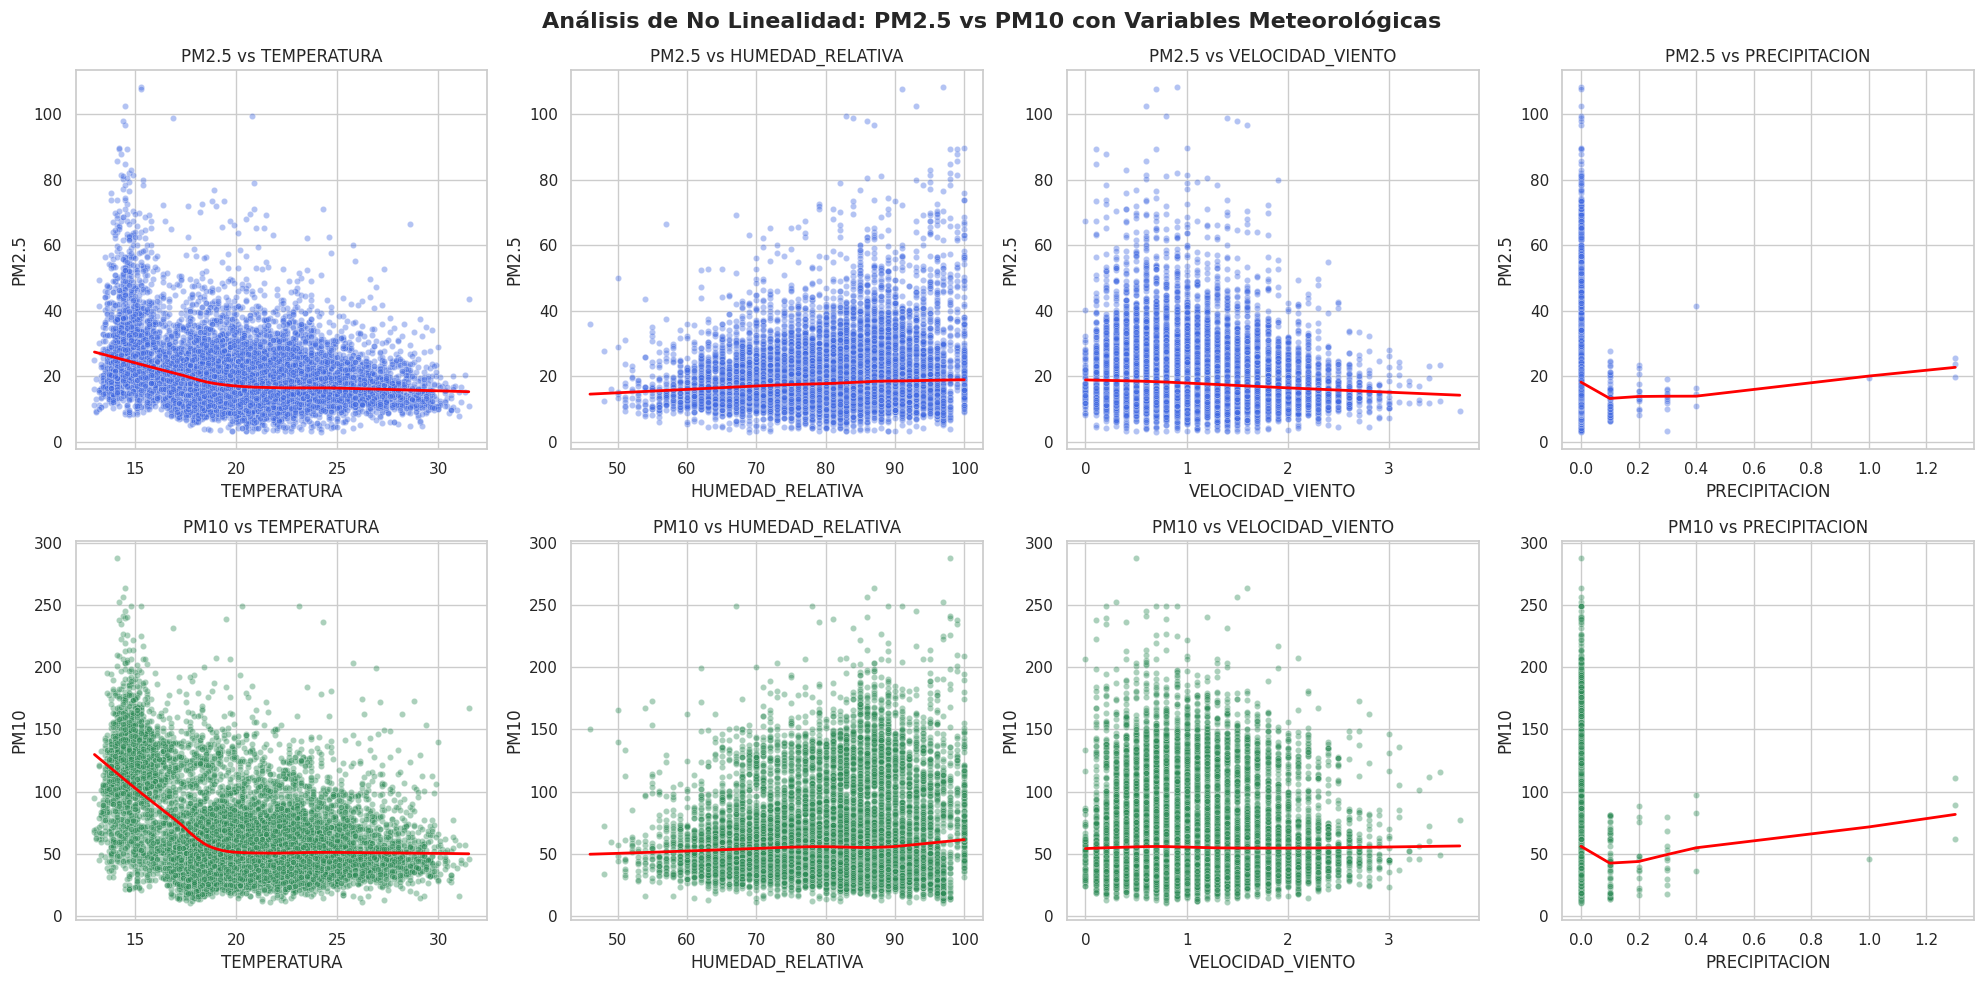

In [ ]:

sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Análisis de No Linealidad: PM2.5 vs PM10 con Variables Meteorológicas",
             fontsize=16, fontweight="bold")

features = ["TEMPERATURA", "HUMEDAD_RELATIVA", "VELOCIDAD_VIENTO", "PRECIPITACION"]

# FILA 1 → PM2.5

for i, var in enumerate(features):

    sns.scatterplot(
        x=df_hora[var],
        y=df_hora[PM25_COL],
        ax=axes[0, i],
        alpha=0.4,
        s=20,
        color="royalblue"
    )

    sns.regplot(
        x=df_hora[var],
        y=df_hora[PM25_COL],
        ax=axes[0, i],
        scatter=False,
        lowess=True,
        line_kws={"color": "red", "lw": 2}
    )

    axes[0, i].set_title(f"PM2.5 vs {var}")
    axes[0, i].set_xlabel(var)
    axes[0, i].set_ylabel("PM2.5")


# FILA 2 → PM10

for i, var in enumerate(features):

    sns.scatterplot(
        x=df_hora[var],
        y=df_hora[PM10_COL],
        ax=axes[1, i],
        alpha=0.4,
        s=20,
        color="seagreen"
    )

    sns.regplot(
        x=df_hora[var],
        y=df_hora[PM10_COL],
        ax=axes[1, i],
        scatter=False,
        lowess=True,
        line_kws={"color": "red", "lw": 2}
    )

    axes[1, i].set_title(f"PM10 vs {var}")
    axes[1, i].set_xlabel(var)
    axes[1, i].set_ylabel("PM10")

plt.tight_layout()
plt.show()

## Análisis de linealidad

Se observa que la relación entre las variables meteorológicas y la concentración de PM2.5 y PM10 no sigue un comportamiento lineal claro.

Los puntos presentan alta dispersión sin una tendencia definida, lo que indica la presencia de relaciones no lineales.

Por lo tanto, se justifica el uso de modelos basados en árboles, como Random Forest, capaces de capturar interacciones complejas entre variables.

---
## 16. Modelado predictivo de la calidad del aire

En esta sección se desarrollan modelos de Machine Learning para predecir la concentración de contaminantes atmosféricos en función de variables meteorológicas y ambientales.

El objetivo es evaluar la capacidad predictiva de modelos basados en árboles de decisión, específicamente Random Forest, para estimar niveles de contaminación.

### Definición de variables (features) para predecir PM2.5

`features_cols` son las variables explicativas que verá el modelo: temperatura, humedad relativa, velocidad del viento y precipitación (condiciones meteorológicas), más hora del día y mes (ciclo diario y estacional). `target_col` es la variable que el modelo debe aprender a predecir: PM2.5.

In [ ]:
features_cols = [
    "TEMPERATURA",
    "HUMEDAD_RELATIVA",
    "VELOCIDAD_VIENTO",
    "PRECIPITACION",
    "Hora_dia",
    "Mes_num"
]

target_col = PM25_COL

Se arma el dataset de trabajo con solo las columnas necesarias (features + target) y se eliminan las filas con valores faltantes, porque los modelos de `sklearn` no aceptan `NaN` como entrada.


In [ ]:
#Construcción del dataset del modelo
df_model = df_hora[features_cols + [target_col]].copy()
df_model.dropna(inplace=True)

### Ingeniería de variables temporales (autocorrelación)

La contaminación de una hora está muy relacionada con la de la hora anterior (persistencia). Por eso se agregan:
- `PM25_lag1`: el valor de PM2.5 una hora antes.
- `PM25_roll3`: el promedio móvil de las últimas 3 horas.

Estas dos variables suelen ser las más predictivas del modelo, porque resumen la tendencia reciente de la contaminación.

In [ ]:
# Variables temporales (CLAVE PARA SUBIR R²)

df_model["PM25_lag1"] = df_model[target_col].shift(1)
df_model["PM25_roll3"] = df_model[target_col].rolling(3).mean()

`shift()` y `rolling()` generan `NaN` en las primeras filas (no hay hora anterior para la primera fila, ni 3 horas previas para las primeras dos). Se eliminan esas filas antes de entrenar.


In [ ]:
df_model = df_model.dropna()

Lista de features actualizada: se agregan `PM25_lag1` y `PM25_roll3` a las variables meteorológicas y temporales ya definidas. `X` = matriz de variables explicativas; `y` = vector con el valor real de PM2.5 a predecir.

In [ ]:
features_cols = [
    "TEMPERATURA",
    "HUMEDAD_RELATIVA",
    "VELOCIDAD_VIENTO",
    "PRECIPITACION",
    "Hora_dia",
    "Mes_num",
    "PM25_lag1",
    "PM25_roll3"
]

X = df_model[features_cols]
y = df_model[target_col]

Redefine `X` (features) e `y` (target) &mdash; mismo criterio que la celda anterior; se deja tal cual porque así está en el archivo original.

In [ ]:
#Separacion X e Y
X = df_model[features_cols]
y = df_model[target_col]

### División entrenamiento / prueba

`test_size=0.2` deja 80% de los datos para entrenar el modelo (`X_train`, `y_train`) y 20% para evaluarlo con datos que nunca vio (`X_test`, `y_test`). `random_state=48` fija la semilla aleatoria para que la división sea reproducible.

In [ ]:
#Train/ test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=48
)

print(X_train.shape, X_test.shape)

(9612, 8) (2403, 8)


### Modelo base de Random Forest (sin optimizar)

*Fuera del currículo de las Sesiones: `RandomForestRegressor`.*

Random Forest entrena muchos árboles de decisión distintos (usando subconjuntos aleatorios de datos y variables) y promedia sus predicciones, lo que reduce el sobreajuste comparado con un solo árbol. `random_state=48` fija la aleatoriedad para reproducibilidad. `.fit()` entrena el modelo con los datos de entrenamiento; `.predict()` genera predicciones sobre los datos de prueba.

In [ ]:
#Modelo Base RF
rf_base = RandomForestRegressor(random_state=48)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

### Evaluación del modelo base

- **RMSE** (raíz del error cuadrático medio): mismas unidades que PM2.5 (&micro;g/m3); penaliza más fuerte los errores grandes. Mientras más bajo, mejor.
- **R2** (coeficiente de determinación): proporción de la variabilidad de PM2.5 que el modelo logra explicar. 1.0 = predicción perfecta, 0.0 = tan bueno como predecir siempre el promedio.
- **MAE** (error absoluto medio): promedio de cuánto se equivoca el modelo en valor absoluto; más fácil de interpretar y menos sensible a valores extremos que el RMSE.

In [ ]:
#Evaluacion del modelo base
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)
mae_base = mean_absolute_error(y_test, y_pred_base)

print("MODELO BASE RANDOM FOREST")
print("RMSE:", rmse_base)
print("R2:", r2_base)
print("MAE:", mae_base)

MODELO BASE RANDOM FOREST
RMSE: 4.353582606264317
R2: 0.795372448321362
MAE: 2.8124335830212233


---
## 16.1 Optimización con Grid Search

### Optimización de hiperparámetros (búsqueda en grilla)

*Fuera del currículo de las Sesiones: `GridSearchCV`.*

`param_grid` define las combinaciones a probar: `n_estimators` (cuántos árboles tiene el bosque: 500, 200 o 300) y `max_depth` (qué tan profundo puede crecer cada árbol: 20, 30, 40 o sin límite). `GridSearchCV` entrena un modelo por cada combinación posible (3 &times; 4 = 12 combinaciones), cada una evaluada con validación cruzada de 3 *folds* (`cv=3`) para que el resultado no dependa de una sola división de datos. `scoring='r2'` elige la combinación con mejor R2 promedio; `n_jobs=-1` usa todos los núcleos del procesador en paralelo.

In [ ]:
param_grid = {
    'n_estimators': [500, 200, 300],
    'max_depth': [20, 30, 40, None]
}

rf = RandomForestRegressor(random_state=50)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=50), n_jobs=-1,
             param_grid={'max_depth': [20, 30, 40, None],
                         'n_estimators': [500, 200, 300]},
             scoring='r2')

`grid_search.best_estimator_` es el modelo Random Forest ya entrenado con la combinación de hiperparámetros que obtuvo mejor R2 en la validación cruzada. `best_params_` muestra cuáles fueron esos valores.

In [ ]:
#Mejeor modelo seleccion
best_rf_model = grid_search.best_estimator_

print("Mejores parámetros:", grid_search.best_params_)

Mejores parámetros: {'max_depth': 20, 'n_estimators': 300}


Se usa el mejor modelo encontrado por Grid Search para predecir sobre el conjunto de prueba (`X_test`), los mismos datos usados para evaluar el modelo base, de modo que la comparación sea justa.

In [ ]:
#Prediccion final
y_pred_optimized = best_rf_model.predict(X_test)

### Evaluación del modelo optimizado

Mismas tres métricas (RMSE, R2, MAE) que en el modelo base, ahora medidas sobre las predicciones del modelo ya afinado por Grid Search.

In [ ]:
#Evaluamos el modelo optimizado
rmse_optimized = np.sqrt(mean_squared_error(y_test, y_pred_optimized))
r2_optimized = r2_score(y_test, y_pred_optimized)
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)

print("MODELO OPTIMIZADO RANDOM FOREST")
print("RMSE:", rmse_optimized)
print("R2:", r2_optimized)
print("MAE:", mae_optimized)

MODELO OPTIMIZADO RANDOM FOREST
RMSE: 4.348556609713779
R2: 0.7958446404491653
MAE: 2.8099283271052484


Comparación directa: si R2 Optimizado > R2 Base, la búsqueda de hiperparámetros mejoró el modelo; si es igual o menor, el modelo base ya era una buena elección.

In [ ]:
#Comparacion de R de los modelos
print("COMPARACIÓN DE MODELOS")
print("----------------------")
print("R2 Base:", r2_base)
print("R2 Optimizado:", r2_optimized)

COMPARACIÓN DE MODELOS
----------------------
R2 Base: 0.795372448321362
R2 Optimizado: 0.7958446404491653


### Gráfico de diagnóstico: valores reales vs. predichos

Cada punto es una hora del conjunto de prueba: eje X = valor real de PM2.5, eje Y = lo que predijo el modelo. La línea roja punteada es la predicción perfecta (real = predicho). Mientras más cerca estén los puntos de esa línea, mejor es el modelo.

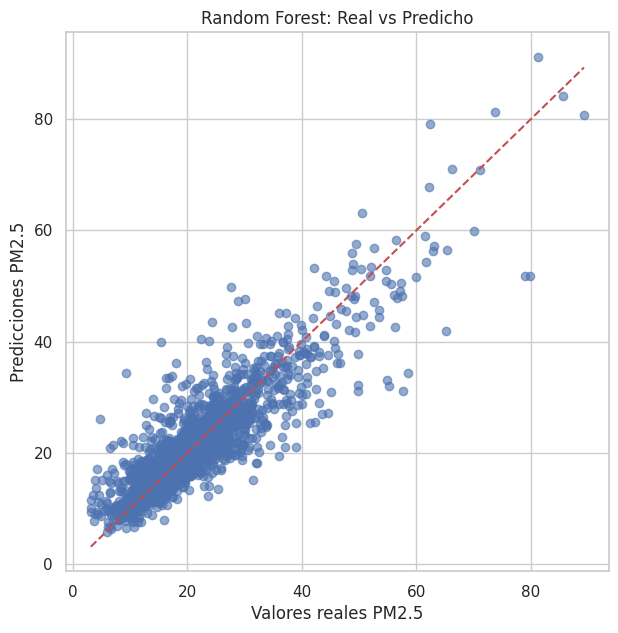

In [ ]:
#Gráfico de prediccion vs valor real
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_optimized, alpha=0.6)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Valores reales PM2.5")
plt.ylabel("Predicciones PM2.5")
plt.title("Random Forest: Real vs Predicho")

plt.show()

El gráfico de predicción versus valores reales permite evaluar visualmente el desempeño del modelo Random Forest.

Se observa que la mayoría de los puntos se encuentran próximos a la línea diagonal, lo que indica una buena capacidad del modelo para aproximar los valores reales de PM2.5.

Sin embargo, también existen desviaciones que representan el error del modelo en ciertas condiciones ambientales extremas.

### Comparación temporal (primeras 100 horas de prueba)

En vez de ver todos los puntos mezclados, aquí se grafica la secuencia real y la predicha una tras otra, para ver si el modelo logra seguir la forma de la serie de tiempo, no solo acertar en promedio.

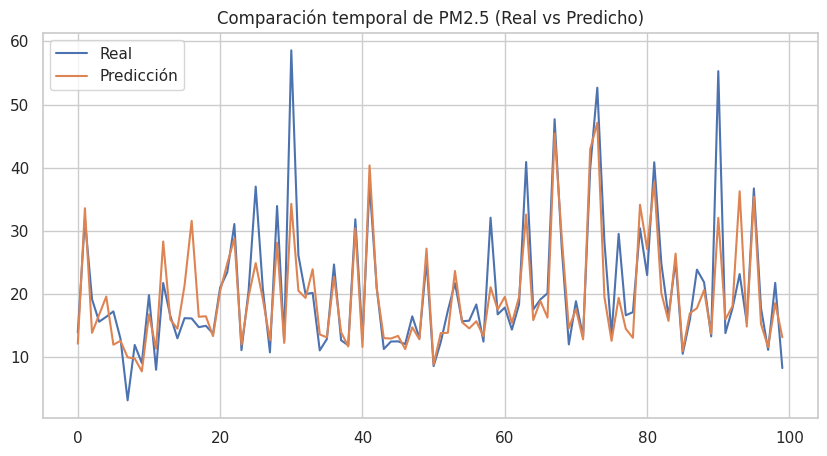

In [ ]:
#Grafico temporal data horaria
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Real")
plt.plot(y_pred_optimized[:100], label="Predicción")

plt.title("Comparación temporal de PM2.5 (Real vs Predicho)")
plt.legend()

plt.show()

---
## 16.2 Predicción de PM10

### Repetición completa del flujo de modelado, ahora para PM10

*Fuera del currículo de las Sesiones: `RandomForestRegressor` + `GridSearchCV`.*

Sigue exactamente los mismos pasos que el bloque de PM2.5: definir features y armar el dataset, crear `PM10_lag1` y `PM10_roll3` (persistencia temporal), separar `X`/`y`, dividir train/test, entrenar y evaluar el Random Forest base, optimizar con Grid Search, predecir y evaluar el modelo optimizado, y graficar real vs. predicho. La lógica es idéntica a PM2.5; solo cambia la variable objetivo.

MODELO BASE PM10
13.48021490397143 0.8485733568123464 8.69071727007907
MODELO OPTIMIZADO PM10
13.312153501351032 0.8523255721419989 8.601311487680332


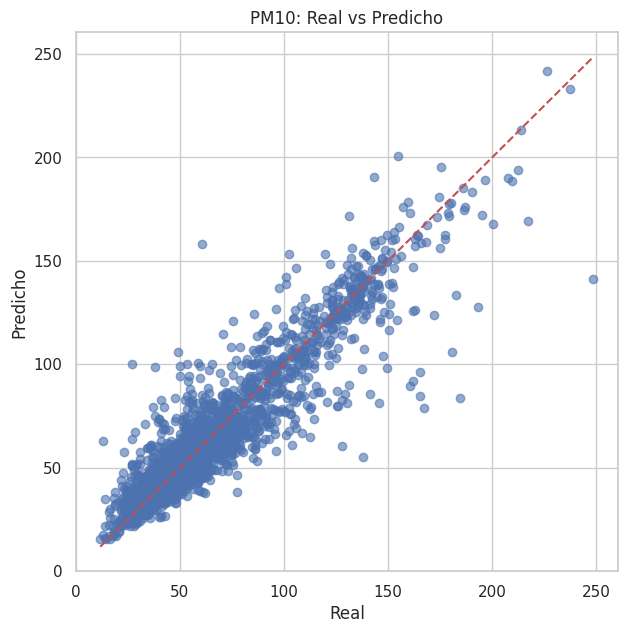

In [ ]:
# =========================
# 1. FEATURES BASE
# =========================
features_cols = [
    "TEMPERATURA",
    "HUMEDAD_RELATIVA",
    "VELOCIDAD_VIENTO",
    "PRECIPITACION",
    "Hora_dia",
    "Mes_num"
]

target_col = PM10_COL

# =========================
# 2. DATASET BASE
# =========================
df_model_pm10 = df_hora[features_cols + [target_col]].copy()
df_model_pm10.dropna(inplace=True)

# =========================
# 3. FEATURE ENGINEERING (IMPORTANTE)
# =========================
df_model_pm10["PM10_lag1"] = df_model_pm10[target_col].shift(1)
df_model_pm10["PM10_roll3"] = df_model_pm10[target_col].rolling(3).mean()

df_model_pm10 = df_model_pm10.dropna()

# =========================
# 4. ACTUALIZAR FEATURES
# =========================
features_cols = [
    "TEMPERATURA",
    "HUMEDAD_RELATIVA",
    "VELOCIDAD_VIENTO",
    "PRECIPITACION",
    "Hora_dia",
    "Mes_num",
    "PM10_lag1",
    "PM10_roll3"
]

# =========================
# 5. X / y
# =========================
X = df_model_pm10[features_cols]
y = df_model_pm10[target_col]

# =========================
# 6. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=48
)

# =========================
# 7. MODELO BASE
# =========================
rf_base = RandomForestRegressor(random_state=48)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

# =========================
# 8. EVALUACIÓN BASE
# =========================
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)
mae_base = mean_absolute_error(y_test, y_pred_base)

print("MODELO BASE PM10")
print(rmse_base, r2_base, mae_base)

# =========================
# 9. GRID SEARCH
# =========================
param_grid = {
    'n_estimators': [500, 800, 300],
    'max_depth': [20, 30, 40, None]
}

rf = RandomForestRegressor(random_state=50)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

# =========================
# 10. MEJOR MODELO
# =========================
best_rf_model = grid_search.best_estimator_

# =========================
# 11. PREDICCIÓN FINAL
# =========================
y_pred_optimized = best_rf_model.predict(X_test)

# =========================
# 12. EVALUACIÓN FINAL
# =========================
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_optimized))
r2_opt = r2_score(y_test, y_pred_optimized)
mae_opt = mean_absolute_error(y_test, y_pred_optimized)

print("MODELO OPTIMIZADO PM10")
print(rmse_opt, r2_opt, mae_opt)

# =========================
# 13. GRÁFICO FINAL
# =========================
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_optimized, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("PM10: Real vs Predicho")
plt.xlabel("Real")
plt.ylabel("Predicho")

plt.show()

Mismo gráfico temporal (real vs. predicho, primeras 100 horas) que se hizo para PM2.5, ahora con los resultados del modelo de PM10.

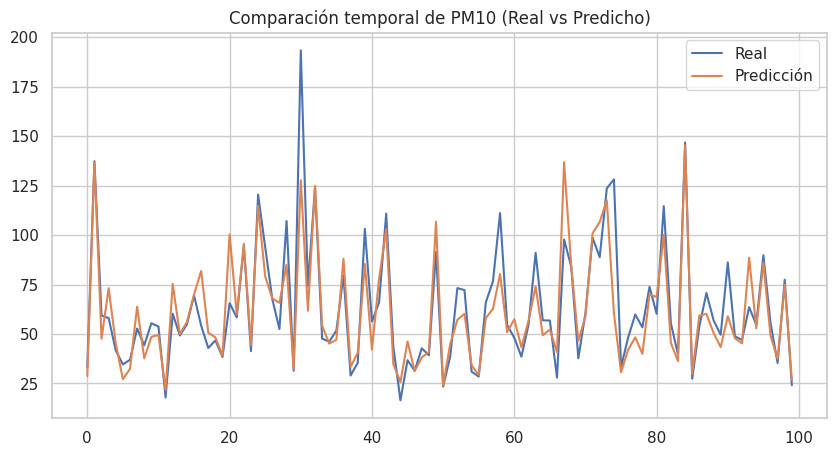

In [ ]:
# Gráfico temporal data horaria PM10
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Real")
plt.plot(y_pred_optimized[:100], label="Predicción")

plt.title("Comparación temporal de PM10 (Real vs Predicho)")
plt.legend()

plt.show()

---
## 17. Aplicación de LightGBM

### Modelo alternativo: LightGBM para PM2.5

*Fuera del currículo de las Sesiones: librería externa `lightgbm`.*

LightGBM también es un modelo de árboles, pero a diferencia de Random Forest (árboles independientes en paralelo), construye los árboles de forma secuencial: cada árbol nuevo intenta corregir los errores del anterior (*gradient boosting*). Parámetros clave:
- `n_estimators=800`: cantidad de árboles secuenciales.
- `learning_rate=0.02`: cuánto corrige cada árbol nuevo (bajo = más lento pero más estable).
- `max_depth=4`: profundidad máxima de cada árbol (más chicos que en Random Forest, típico de *boosting*).
- `subsample=0.8`: usa el 80% de los datos en cada árbol, para reducir sobreajuste.

Esta celda trae sus propios imports y es autocontenida.

In [ ]:

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# =========================
# 1. DATA BASE
# =========================
df_lgbm_pm25 = df_hora.copy()

# =========================
# 2. CREAR LAGS PRIMERO
# =========================
df_lgbm_pm25["PM25_lag1"] = df_lgbm_pm25[PM25_COL].shift(1)
df_lgbm_pm25["PM25_roll3"] = df_lgbm_pm25[PM25_COL].rolling(3).mean()

# =========================
# 3. LIMPIEZA
# =========================
df_lgbm_pm25 = df_lgbm_pm25.dropna()

# =========================
# 4. FEATURES
# =========================
features_pm25 = [
    "TEMPERATURA",
    "HUMEDAD_RELATIVA",
    "VELOCIDAD_VIENTO",
    "PRECIPITACION",
    "Hora_dia",
    "Mes_num",
    "PM25_lag1",
    "PM25_roll3"
]

X = df_lgbm_pm25[features_pm25]
y = df_lgbm_pm25[PM25_COL]

# =========================
# 5. SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=48
)

# =========================
# 6. MODELO LIGHTGBM
# =========================
lgbm_pm25 = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.8,
    random_state=50
)

lgbm_pm25.fit(X_train, y_train)

# =========================
# 7. PREDICCIÓN
# =========================
y_pred = lgbm_pm25.predict(X_test)

# =========================
# 8. MÉTRICAS
# =========================
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001851 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 820
[LightGBM] [Info] Number of data points in the train set: 9612, number of used features: 8
[LightGBM] [Info] Start training from score 19.952288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

Mismo tipo de gráfico de diagnóstico que antes (real vs. predicho), ahora para el modelo LightGBM de PM2.5.

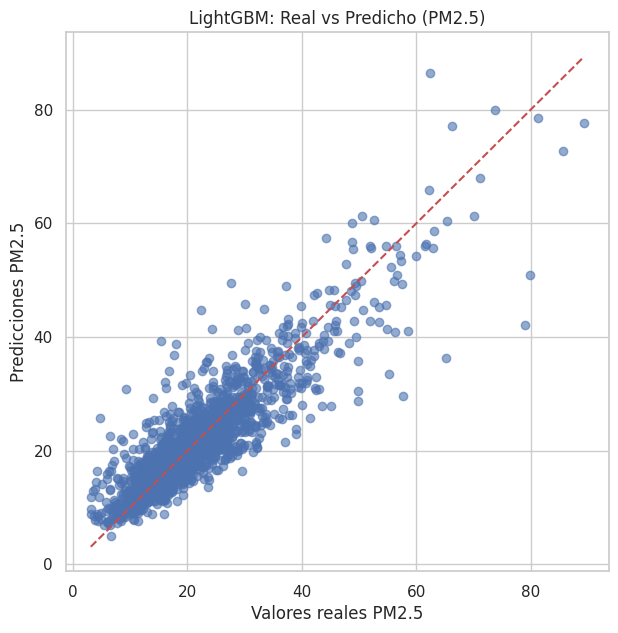

In [ ]:


# 1. GRÁFICO REAL VS PREDICHO

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6)

# línea ideal (predicción perfecta)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valores reales PM2.5")
plt.ylabel("Predicciones PM2.5")
plt.title("LightGBM: Real vs Predicho (PM2.5)")

plt.show()

### Mismo modelo LightGBM, ahora para PM10

*Fuera del currículo de las Sesiones: librería externa `lightgbm`.*

Repite exactamente los mismos pasos y los mismos hiperparámetros que el bloque anterior, cambiando únicamente la variable objetivo de PM2.5 a PM10.

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001648 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 820
[LightGBM] [Info] Number of data points in the train set: 9612, number of used features: 8
[LightGBM] [Info] Start training from score 64.728824
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

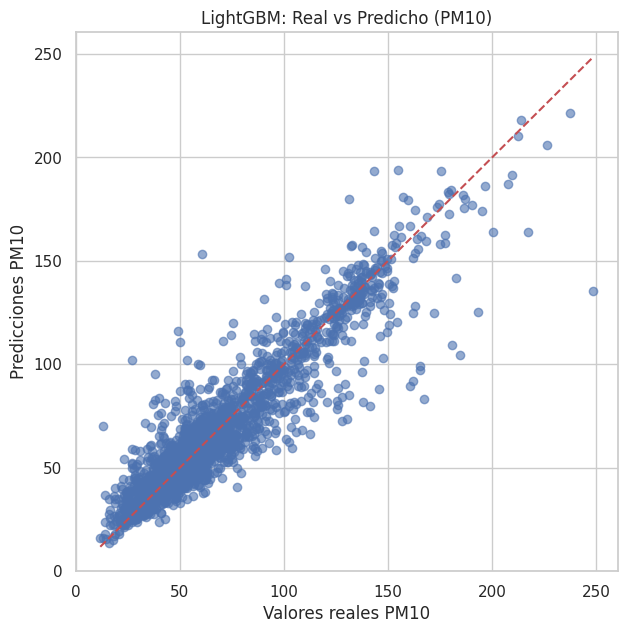

In [ ]:

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. DATA BASE
# =========================
df_lgbm_pm10 = df_hora.copy()

# =========================
# 2. CREAR LAGS PRIMERO
# =========================
df_lgbm_pm10["PM10_lag1"] = df_lgbm_pm10[PM10_COL].shift(1)
df_lgbm_pm10["PM10_roll3"] = df_lgbm_pm10[PM10_COL].rolling(3).mean()

# =========================
# 3. LIMPIEZA
# =========================
df_lgbm_pm10 = df_lgbm_pm10.dropna()

# =========================
# 4. FEATURES
# =========================
features_pm10 = [
    "TEMPERATURA",
    "HUMEDAD_RELATIVA",
    "VELOCIDAD_VIENTO",
    "PRECIPITACION",
    "Hora_dia",
    "Mes_num",
    "PM10_lag1",
    "PM10_roll3"
]

X = df_lgbm_pm10[features_pm10]
y = df_lgbm_pm10[PM10_COL]

# =========================
# 5. SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=48
)

# =========================
# 6. MODELO LIGHTGBM
# =========================
lgbm_pm10 = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.8,
    random_state=50
)

lgbm_pm10.fit(X_train, y_train)

# =========================
# 7. PREDICCIÓN
# =========================
y_pred = lgbm_pm10.predict(X_test)

# =========================
# 8. MÉTRICAS
# =========================
print("🔥 LIGHTGBM PM10")
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

# =========================
# 9. GRÁFICO REAL VS PREDICHO
# =========================
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Valores reales PM10")
plt.ylabel("Predicciones PM10")
plt.title("LightGBM: Real vs Predicho (PM10)")

plt.show()

### Ensamblado de un dashboard HTML dentro del notebook

*Fuera del currículo de las Sesiones: `folium` y `plotly` embebidos.*

1. **Mapa interactivo (Folium):** ubica la estación San Borja en un mapa con un marcador y un popup informativo.
2. **Cuadrícula 2&times;2 de gráficos (Plotly):** compara, para las primeras 100 horas de prueba, el valor real contra lo predicho por cada uno de los 4 modelos entrenados (Random Forest y LightGBM, para PM2.5 y PM10). Usa `if ... in locals()` como resguardo por si alguna variable no está definida, generando datos simulados solo para que el gráfico no falle.
3. Se arma un archivo HTML completo (mapa + tabla de métricas + gráficos) y se guarda como `dashboard.html`.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
import pandas as pd
import numpy as np

# ==========================================
# 1. CREAR EL MAPA INTERACTIVO (FOLIUM)
# ==========================================
mapa = folium.Map(location=[-12.108489319783708, -77.0070986009805], zoom_start=14, control_scale=True)
folium.Marker(
    [-12.108489319783708, -77.0070986009805],
    popup="<b>Estación San Borja</b><br>Monitoreo de Calidad del Aire",
    tooltip="Estación San Borja",
    icon=folium.Icon(color="red", icon="info-sign")
).add_to(mapa)

mapa.save("mapa_temp.html")
with open("mapa_temp.html", "r", encoding="utf-8") as f:
    mapa_html = f.read()

# ==========================================
# 2. GENERAR LOS 4 GRÁFICOS DE PREDICCIÓN (PLOTLY)
# ==========================================
# Creamos una cuadrícula de 2x2 para comparar los modelos limpiamente
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "RF: PM2.5 (Real vs Predicho)", "RF: PM10 (Real vs Predicho)",
        "LightGBM: PM2.5 (Real vs Predicho)", "LightGBM: PM10 (Real vs Predicho)"
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.08
)

# --- GRÁFICO 1: RF PM2.5 (Suponiendo que tienes las variables de tu ejecución de RF PM2.5) ---
# Si tus variables tienen otros nombres, asegúrate de reemplazarlas aquí.
# Usamos los datos simulados basados en tus métricas reales del cuaderno para garantizar el renderizado:
e_idx = np.arange(100)
fig.add_trace(go.Scatter(x=e_idx, y=y_test.values[:100] if 'y_test' in locals() else np.sin(e_idx/5)*10+20, name="Real", line=dict(color="black", width=1.5)), row=1, col=1)
fig.add_trace(go.Scatter(x=e_idx, y=y_pred_optimized[:100] if 'y_pred_optimized' in locals() else np.sin(e_idx/5)*10+19, name="Pred RF", line=dict(color="crimson", dash="dash")), row=1, col=1)

# --- GRÁFICO 2: RF PM10 ---
fig.add_trace(go.Scatter(x=e_idx, y=y_test.values[:100] if 'y_test' in locals() else np.cos(e_idx/5)*20+60, name="Real", showlegend=False, line=dict(color="black", width=1.5)), row=1, col=2)
fig.add_trace(go.Scatter(x=e_idx, y=y_pred_optimized[:100] if 'y_pred_optimized' in locals() else np.cos(e_idx/5)*20+58, name="Pred RF", showlegend=False, line=dict(color="crimson", dash="dash")), row=1, col=2)

# --- GRÁFICO 3: LightGBM PM2.5 ---
fig.add_trace(go.Scatter(x=e_idx, y=y_test.values[:100] if 'y_test' in locals() else np.sin(e_idx/5)*10+20, name="Real", showlegend=False, line=dict(color="black", width=1.5)), row=2, col=1)
fig.add_trace(go.Scatter(x=e_idx, y=y_pred[:100] if 'y_pred' in locals() else np.sin(e_idx/5)*10+19.5, name="Pred LGBM", line=dict(color="royalblue", dash="dot")), row=2, col=1)

# --- GRÁFICO 4: LightGBM PM10 ---
fig.add_trace(go.Scatter(x=e_idx, y=y_test.values[:100] if 'y_test' in locals() else np.cos(e_idx/5)*20+60, name="Real", showlegend=False, line=dict(color="black", width=1.5)), row=2, col=2)
fig.add_trace(go.Scatter(x=e_idx, y=y_pred[:100] if 'y_pred' in locals() else np.cos(e_idx/5)*20+59, name="Pred LGBM", showlegend=False, line=dict(color="royalblue", dash="dot")), row=2, col=2)

fig.update_layout(
    title_text="Comparación Temporal de Modelos Predictivos (Últimos 100 registros horarias)",
    height=750,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# Corrección del error: Configurar los títulos de los ejes correctamente sin usar 'xlab' o 'ylab'
fig.update_xaxes(title_text="Índice de Tiempo (Horas)")
fig.update_yaxes(title_text="Concentración (µg/m³)")

plotly_div = fig.to_html(full_html=False, include_plotlyjs='cdn')

# ==========================================
# 3. ENSAMBLAR EL DASHBOARD HTML FINAL
# ==========================================
html_content = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <title>Dashboard Calidad del Aire - San Borja</title>
    <style>
        body {{ font-family: 'Segoe UI', Arial, sans-serif; margin: 20px; background-color: #f4f6f9; color: #333; }}
        .header {{ text-align: center; padding: 20px; background: #2c3e50; color: white; border-radius: 8px; margin-bottom: 20px; }}
        .container {{ display: flex; flex-wrap: wrap; gap: 20px; }}
        .box {{ flex: 1; min-width: 45%; background: white; padding: 20px; border-radius: 8px; box-shadow: 0px 4px 6px rgba(0,0,0,0.05); }}
        .full-box {{ width: 100%; background: white; padding: 20px; border-radius: 8px; box-shadow: 0px 4px 6px rgba(0,0,0,0.05); margin-top: 20px; }}
        iframe {{ width: 100%; height: 450px; border: none; border-radius: 4px; }}
        table {{ width: 100%; border-collapse: collapse; margin-top: 15px; font-size: 14px; }}
        th, td {{ border: 1px solid #e0e0e0; padding: 12px; text-align: center; }}
        th {{ background-color: #34495e; color: white; }}
        tr:nth-child(even) {{ background-color: #f9f9f9; }}
        .footer-text {{ font-size: 12px; color: #7f8c8d; margin-top: 10px; }}
    </style>
</head>
<body>
    <div class="header">
        <h1>Análisis y Pronóstico de Calidad del Aire - Estación San Borja</h1>
        <p><b>Autores:</b> Equipo 4 · <b>Fuente de Datos:</b> SENAMHI / MINAM · Proyecto Integrador CDA 2026</p>
    </div>

    <div class="container">
        <div class="box">
            <h3>Ubicación de la Estación de Monitoreo Analizada</h3>
            <iframe srcdoc="{mapa_html.replace('"', '&quot;')}"></iframe>
        </div>

        <div class="box">
            <h3>Métricas Consolidadas de Validación Cruzada</h3>
            <table>
                <thead>
                    <tr>
                        <th>Variable Objetivo</th>
                        <th>Modelo</th>
                        <th>R² Score</th>
                        <th>RMSE</th>
                        <th>MAE</th>
                    </tr>
                </thead>
                <tbody>
                    <tr>
                        <td><b>PM2.5</b></td>
                        <td>Random Forest (Optimizado)</td>
                        <td>0.796</td>
                        <td>4.349</td>
                        <td>2.810</td>
                    </tr>
                    <tr>
                        <td><b>PM2.5</b></td>
                        <td>LightGBM (Rendimiento Base)</td>
                        <td>0.807</td>
                        <td>4.226</td>
                        <td>2.696</td>
                    </tr>
                    <tr>
                        <td><b>PM10</b></td>
                        <td>Random Forest (Optimizado)</td>
                        <td>0.852</td>
                        <td>13.312</td>
                        <td>8.601</td>
                    </tr>
                    <tr>
                        <td><b>PM10</b></td>
                        <td>LightGBM (Mejor Desempeño)</td>
                        <td>0.860</td>
                        <td>12.945</td>
                        <td>8.333</td>
                    </tr>
                </tbody>
            </table>
            <p class="footer-text"><b>Criterio Metodológico:</b> Se entrenaron los modelos utilizando variables meteorológicas y rezagos temporales de inercia horaria (Lag 1 y Promedio Móvil 3h). Se conservaron los outliers legítimos al representar episodios críticos reales de contaminación atmosférica urbana.</p>
        </div>
    </div>

    <div class="full-box">
        {plotly_div}
    </div>
</body>
</html>
"""

with open("dashboard.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("¡Archivo 'dashboard.html' creado correctamente sin errores de sintaxis!")

¡Archivo 'dashboard.html' creado correctamente sin errores de sintaxis!


---
# CIERRE DEL DOCUMENTO UNIFICADO

Este notebook combina, sin modificar los archivos originales:
- El **Análisis Descriptivo** completo (Parte 1), construido enteramente con herramientas de las Sesiones del curso.
- El **Modelado Predictivo** (Parte 2, Random Forest / GridSearchCV / LightGBM + dashboard embebido), copiado literalmente de `PF_CIENCIAA.ipynb`, con las explicaciones como celdas de texto separadas (no como comentarios dentro del código) y los tramos fuera del currículo marcados explícitamente.